# Google Merchandise Store — Funnel Analysis
## Phase 3: Data Cleaning and Preparation

**Dataset:** Google Merchandise Store GA4 event data  
**Period:** November 2020 — January 2021  
**Files:** events1.csv, items.csv, users.csv  
**Schema:** Star schema — events (fact) + users + items (dimensions)  
**Funnel:** Add to Cart → Begin Checkout → Purchase

### Professional cleaning decisions log
Every decision in this notebook is driven by what the data
represents in the real world — not by generic rules.

In [2]:
import pandas as pd 
import numpy as np 
import os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',100)
pd.set_option('display.float_format','{:.2f}'.format)

print("Libraries Loaded")
print(f" pandas: {pd.__version__}")
print(f" numpy: {np.__version__}")

Libraries Loaded
 pandas: 2.3.3
 numpy: 2.4.3


In [3]:
BASE = '../data/raw/google/'

events = pd.read_csv(BASE + 'events1.csv')
items  = pd.read_csv(BASE + 'items.csv')
users  = pd.read_csv(BASE + 'users.csv')

print("✓ Raw files loaded")
print(f"  events : {events.shape[0]:>7,} rows × {events.shape[1]} cols")
print(f"  items  : {items.shape[0]:>7,} rows × {items.shape[1]} cols")
print(f"  users  : {users.shape[0]:>7,} rows × {users.shape[1]} cols")

✓ Raw files loaded
  events : 758,884 rows × 7 cols
  items  :   1,381 rows × 6 cols
  users  : 270,154 rows × 3 cols


In [4]:
print("=" * 60)
print("EVENTS — raw structure")
print("=" * 60)
print(f"\nShape: {events.shape}")
print(f"\nDtypes:\n{events.dtypes}")
print(f"\nSample (3 rows):")
display(events.head(3))

print("\n" + "=" * 60)
print("ITEMS — raw structure")
print("=" * 60)
print(f"\nShape: {items.shape}")
print(f"\nDtypes:\n{items.dtypes}")
display(items.head(3))

print("\n" + "=" * 60)
print("USERS — raw structure")
print("=" * 60)
print(f"\nShape: {users.shape}")
print(f"\nDtypes:\n{users.dtypes}")
display(users.head(3))

EVENTS — raw structure

Shape: (758884, 7)

Dtypes:
user_id           int64
ga_session_id     int64
country          object
device           object
type             object
item_id           int64
date             object
dtype: object

Sample (3 rows):


,user_id,ga_session_id,country,device,type,item_id,date
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44



ITEMS — raw structure

Shape: (1381, 6)

Dtypes:
id               int64
name            object
brand           object
variant         object
category        object
price_in_usd     int64
dtype: object


,id,name,brand,variant,category,price_in_usd
0,0,Google Land & Sea Cotton Cap,Google,Single Option Only,Apparel,14
1,1,Google KeepCup,Google,Single Option Only,New,28
2,2,Google Land & Sea Nalgene Water Bottle,Google,Single Option Only,Drinkware,20



USERS — raw structure

Shape: (270154, 3)

Dtypes:
id       int64
ltv      int64
date    object
dtype: object


,id,ltv,date
0,0,0,2020-10-13 05:08:47
1,1,0,2020-11-24 14:26:54
2,2,0,2020-11-24 06:19:54


In [5]:
print("MISSING VALUES AUDIT")
print("=" * 60)

for name, df in [('EVENTS', events), ('ITEMS', items), ('USERS', users)]:
    missing  = df.isnull().sum()
    pct      = (missing / len(df) * 100).round(2)
    report   = pd.DataFrame({'count': missing, 'pct_%': pct})
    report   = report[report['count'] > 0]

    print(f"\n{name} ({len(df):,} rows)")
    if len(report) == 0:
        print("  → No missing values")
    else:
        print(report)
        for col in report.index:
            print(f"\n  [{col}] — inspect unique non-null values:")
            print(f"  {df[col].dropna().value_counts().head(5).to_dict()}")

MISSING VALUES AUDIT

EVENTS (758,884 rows)
         count  pct_%
country   4555   0.60

  [country] — inspect unique non-null values:


  {'US': 337513, 'IN': 68392, 'CA': 61126, 'GB': 23128, 'ES': 16191}

ITEMS (1,381 rows)
         count  pct_%
variant    408  29.54

  [variant] — inspect unique non-null values:
  {'Single Option Only': 263, ' LG': 91, ' MD': 90, ' SM': 86, ' XL': 79}

USERS (270,154 rows)
  → No missing values


In [6]:
print("INVESTIGATING: items['variant'] — 29.54% nulls")
print("=" * 60)

# what does variant contain when it's NOT null?
print("Non-null variant values:")
print(items['variant'].value_counts())

print(f"\nNull variant rows — what categories are they?")
null_variant_items = items[items['variant'].isnull()]
print(null_variant_items['category'].value_counts())

print(f"\nNon-null variant rows — what categories are they?")
notnull_variant_items = items[items['variant'].notna()]
print(notnull_variant_items['category'].value_counts().head(10))

print(f"\nSample null-variant rows:")
display(null_variant_items[['name','category','price_in_usd']].head(10))

INVESTIGATING: items['variant'] — 29.54% nulls
Non-null variant values:
variant
Single Option Only      263
 LG                      91
 MD                      90
 SM                      86
 XL                      79
 2XL                     63
 XS                      62
LG                       44
 3XL                     38
MD                       31
XL                       21
SM                       16
XS                        9
 3T                       8
 2T                       7
 4T                       7
 18/24 MONTHS             6
 5/6T                     6
 3/6 MONTHS               4
 6/12 MONTHS              4
Choose Size               4
 12/18 MONTHS             4
2XL                       3
3/6 MONTHS                3
3XL                       2
2T                        2
No options available      2
3T                        2
 6M                       1
 XXS                      1
 18M                      1
 24M                      1
 5T                     

,name,category,price_in_usd
835,Google Black Cloud Zip Hoodie,Apparel,69
837,Google Women's Kirkland Pullover,Apparel,63
839,Android Pocket Onesie White,Apparel,22
840,Android Pocket Onesie Navy,Apparel,22
841,Google Beekeepers Onesie Pink,Apparel,25
842,Google Infant Hero Onesie Grey,Apparel,25
843,Google Infant Hero Tee Olive,Apparel,25
845,Google Crew Striped Athletic Sock,Apparel,17
846,Google Mural Socks,New,15
847,Google Crew Combed Cotton Sock,Apparel,17


In [7]:
print("INVESTIGATING: items['variant'] — 29.54% nulls")
print("=" * 60)

print("Non-null variant values:")
print(items['variant'].value_counts())

print(f"\nNull variant rows — what categories are they?")
null_variant_items = items[items['variant'].isnull()]
print(null_variant_items['category'].value_counts())

print(f"\nSample null-variant rows:")
display(null_variant_items[['name','category','price_in_usd']].head(10))

INVESTIGATING: items['variant'] — 29.54% nulls
Non-null variant values:
variant
Single Option Only      263
 LG                      91
 MD                      90
 SM                      86
 XL                      79
 2XL                     63
 XS                      62
LG                       44
 3XL                     38
MD                       31
XL                       21
SM                       16
XS                        9
 3T                       8
 2T                       7
 4T                       7
 18/24 MONTHS             6
 5/6T                     6
 3/6 MONTHS               4
 6/12 MONTHS              4
Choose Size               4
 12/18 MONTHS             4
2XL                       3
3/6 MONTHS                3
3XL                       2
2T                        2
No options available      2
3T                        2
 6M                       1
 XXS                      1
 18M                      1
 24M                      1
 5T                     

,name,category,price_in_usd
835,Google Black Cloud Zip Hoodie,Apparel,69
837,Google Women's Kirkland Pullover,Apparel,63
839,Android Pocket Onesie White,Apparel,22
840,Android Pocket Onesie Navy,Apparel,22
841,Google Beekeepers Onesie Pink,Apparel,25
842,Google Infant Hero Onesie Grey,Apparel,25
843,Google Infant Hero Tee Olive,Apparel,25
845,Google Crew Striped Athletic Sock,Apparel,17
846,Google Mural Socks,New,15
847,Google Crew Combed Cotton Sock,Apparel,17


In [8]:
print("FIXING: variant column casing and whitespace")
print("=" * 60)

print("Before fix — unique values with hidden spaces:")
print(repr(items['variant'].dropna().unique()[:10]))

# strip leading/trailing whitespace — this is the root cause
items['variant'] = items['variant'].str.strip()

print("\nAfter fix — cleaned unique values:")
print(items['variant'].value_counts().head(15))

# verify LG consolidation worked
print(f"\nLG count before fix : 91 + 44 = 135 (split by whitespace)")
print(f"LG count after fix  : {(items['variant'] == 'LG').sum()}")

FIXING: variant column casing and whitespace
Before fix — unique values with hidden spaces:
array(['Single Option Only', ' LG', ' MD', ' SM', ' XS', ' 3/6 MONTHS',
       ' XL', ' 6/12 MONTHS', ' 3T', ' 2XL'], dtype=object)

After fix — cleaned unique values:
variant
Single Option Only    263
LG                    135
MD                    121
SM                    102
XL                    100
XS                     71
2XL                    66
3XL                    40
3T                     10
2T                      9
4T                      8
3/6 MONTHS              7
5/6T                    7
18/24 MONTHS            6
6/12 MONTHS             5
Name: count, dtype: int64

LG count before fix : 91 + 44 = 135 (split by whitespace)
LG count after fix  : 135


In [9]:
print("TREATING: items['variant'] nulls")
print("=" * 60)

# re-examine null rows after whitespace fix
null_variant = items[items['variant'].isnull()]
print(f"Null variant items  : {len(null_variant)}")
print(f"\nCategory breakdown of null-variant items:")
print(null_variant['category'].value_counts())

print(f"\nSample null-variant product names:")
for name in null_variant['name'].head(15).tolist():
    print(f"  {name}")

TREATING: items['variant'] nulls
Null variant items  : 408

Category breakdown of null-variant items:
category
Apparel                    102
Campus Collection           64
New                         42
Accessories                 41
Clearance                   28
Bags                        25
Shop by Brand               21
Office                      17
Lifestyle                   13
Drinkware                   12
Uncategorized Items         11
Stationery                   8
Small Goods                  6
Writing Instruments          5
Google                       4
Gift Cards                   4
Notebooks & Journals         2
Electronics Accessories      1
Eco-Friendly                 1
Fun                          1
Name: count, dtype: int64

Sample null-variant product names:
  Google Black Cloud Zip Hoodie
  Google Women's Kirkland Pullover
  Android Pocket Onesie White
  Android Pocket Onesie Navy
  Google Beekeepers Onesie Pink
  Google Infant Hero Onesie Grey
  Google Infant 

In [10]:
print("APPLYING VARIANT TREATMENT")
print("=" * 60)

# DECISION LOGIC:
# 1. Apparel items with null variant = size not recorded in catalog
#    → fill with 'Size Not Specified'
#    → reason: these ARE sized products, the gap is a catalog error
#    → NOT 'Unknown' — that implies we don't know the product type
#    → NOT 'Single Option Only' — that would be factually wrong

# 2. Non-apparel items with null variant = genuinely no variant
#    → fill with 'Single Option Only'

apparel_categories = ['Apparel', 'Campus Collection', 'Clearance']

def fill_variant(row):
    if pd.notna(row['variant']):
        return row['variant']
    elif row['category'] in apparel_categories:
        return 'Size Not Specified'
    else:
        return 'Single Option Only'

items['variant'] = items.apply(fill_variant, axis=1)

print("Variant distribution after treatment:")
print(items['variant'].value_counts())

print(f"\nRemaining nulls in variant: {items['variant'].isnull().sum()}")
print(f"\n✓ Decision: context-aware fill")
print(f"  Apparel nulls  → 'Size Not Specified' (catalog gap)")
print(f"  Other nulls    → 'Single Option Only' (no variant applicable)")

APPLYING VARIANT TREATMENT
Variant distribution after treatment:
variant
Single Option Only      477
Size Not Specified      194
LG                      135
MD                      121
SM                      102
XL                      100
XS                       71
2XL                      66
3XL                      40
3T                       10
2T                        9
4T                        8
3/6 MONTHS                7
5/6T                      7
18/24 MONTHS              6
12/18 MONTHS              5
6/12 MONTHS               5
Choose Size               4
No options available      2
BLUE                      2
NEWBORN                   2
GREEN                     1
RED                       1
12M                       1
5T                        1
6M                        1
24M                       1
18M                       1
XXS                       1
Name: count, dtype: int64

Remaining nulls in variant: 0

✓ Decision: context-aware fill
  Apparel nulls  → 'Size N

In [11]:
print("VALIDATION — does treatment make business sense?")
print("=" * 60)

# apparel items should now have size variants or 'Size Not Specified'
apparel_items = items[items['category'] == 'Apparel']
print("Apparel variant distribution after fix:")
print(apparel_items['variant'].value_counts())

# non-apparel items should have Single Option Only or specific variants
non_apparel = items[items['category'] == 'Drinkware']
print(f"\nDrinkware variant distribution (should be Single Option Only):")
print(non_apparel['variant'].value_counts())

# final check — zero nulls remaining
print(f"\nFinal null check across items table:")
print(items.isnull().sum())

VALIDATION — does treatment make business sense?
Apparel variant distribution after fix:
variant
Size Not Specified      102
LG                       86
MD                       74
XL                       67
SM                       65
2XL                      42
XS                       42
3XL                      24
Single Option Only       11
3T                       10
2T                        9
4T                        8
5/6T                      7
3/6 MONTHS                7
18/24 MONTHS              6
6/12 MONTHS               5
12/18 MONTHS              5
Choose Size               3
NEWBORN                   2
12M                       1
5T                        1
18M                       1
6M                        1
24M                       1
XXS                       1
No options available      1
Name: count, dtype: int64

Drinkware variant distribution (should be Single Option Only):
variant
Single Option Only    24
Name: count, dtype: int64

Final null check across i

In [12]:
print("FIXING: 'Choose Size' placeholder value")
print("=" * 60)

before = (items['variant'] == 'Choose Size').sum()
items['variant'] = items['variant'].replace('Choose Size', 'Size Not Specified')
after = (items['variant'] == 'Choose Size').sum()

print(f"'Choose Size' entries replaced : {before}")
print(f"Remaining 'Choose Size'        : {after}")
print(f"\n✓ UI placeholder removed — merged into 'Size Not Specified'")

FIXING: 'Choose Size' placeholder value
'Choose Size' entries replaced : 4
Remaining 'Choose Size'        : 0

✓ UI placeholder removed — merged into 'Size Not Specified'


In [13]:
print("TREATING: events['country'] — Random missing")
print("=" * 60)

# inspect null rows — any pattern by device or event type?
null_country_rows = events[events['country'].isnull()]

print(f"Null country rows   : {len(null_country_rows):,} ({len(null_country_rows)/len(events)*100:.1f}%)")
print(f"\nDevice breakdown of null-country rows:")
print(null_country_rows['device'].value_counts())
print(f"\nEvent type breakdown of null-country rows:")
print(null_country_rows['type'].value_counts())

# DECISION: fill with 'Unknown'
# Reason: no device/event pattern = random tracking gap
# Never fill with mode (US) — would inflate US traffic numbers
events['country'] = events['country'].fillna('Unknown')

print(f"\n✓ Filled with 'Unknown'")
print(f"  Remaining nulls: {events['country'].isnull().sum()}")

TREATING: events['country'] — Random missing
Null country rows   : 4,555 (0.6%)

Device breakdown of null-country rows:
device
desktop    2633
mobile     1872
tablet       50
Name: count, dtype: int64

Event type breakdown of null-country rows:
type
add_to_cart       3977
begin_checkout     498
purchase            80
Name: count, dtype: int64



✓ Filled with 'Unknown'
  Remaining nulls: 0


In [14]:
print("TREATING: users['ltv'] — Structural zeros")
print("=" * 60)

print(f"LTV distribution:")
print(users['ltv'].describe())
print(f"\nUsers with LTV = 0  : {(users['ltv'] == 0).sum():,} ({(users['ltv']==0).mean()*100:.1f}%)")
print(f"Users with LTV > 0  : {(users['ltv'] > 0).sum():,} ({(users['ltv']>0).mean()*100:.1f}%)")

# DECISION: keep zeros, create segment flag
# Reason: zero IS the correct value — genuine non-buyers
# Filling with median fabricates purchasing behavior
users['is_paying_customer'] = (users['ltv'] > 0).astype(int)

print(f"\n✓ Zeros kept as-is")
print(f"  Added: 'is_paying_customer' flag")
print(f"\nBreakdown:")
print(users['is_paying_customer'].value_counts())

TREATING: users['ltv'] — Structural zeros
LTV distribution:
count   270154.00
mean         1.51
std         19.77
min          0.00
25%          0.00
50%          0.00
75%          0.00
max       3360.00
Name: ltv, dtype: float64

Users with LTV = 0  : 265,709 (98.4%)
Users with LTV > 0  : 4,445 (1.6%)

✓ Zeros kept as-is
  Added: 'is_paying_customer' flag

Breakdown:
is_paying_customer
0    265709
1      4445
Name: count, dtype: int64


In [15]:
print("DUPLICATE AUDIT")
print("=" * 60)

for name, df in [('EVENTS', events), ('ITEMS', items), ('USERS', users)]:
    exact_dupes = df.duplicated().sum()
    print(f"{name:<8} exact duplicates: {exact_dupes:,}")

# logical duplicates — same user+session+event+item+timestamp
logical_dupes = events.duplicated(
    subset=['user_id','ga_session_id','type','item_id','date']
).sum()
print(f"\nLogical duplicates in events: {logical_dupes:,}")

before = len(events)
events = events.drop_duplicates()
events = events.drop_duplicates(
    subset=['user_id','ga_session_id','type','item_id','date']
)
after = len(events)

print(f"\n✓ Removed: {before - after:,} rows")
print(f"  Rows remaining: {after:,}")

DUPLICATE AUDIT


EVENTS   exact duplicates: 39,498
ITEMS    exact duplicates: 0
USERS    exact duplicates: 0

Logical duplicates in events: 39,498

✓ Removed: 39,498 rows
  Rows remaining: 719,386


In [16]:
print("DATA TYPE FIXES + TIME FEATURES")
print("=" * 60)

# date: string → datetime
print(f"date before : {events['date'].dtype}")
events['date'] = pd.to_datetime(events['date'])
print(f"date after  : {events['date'].dtype}")

# extract time features
events['year']        = events['date'].dt.year
events['month']       = events['date'].dt.month
events['month_name']  = events['date'].dt.strftime('%B')
events['day_of_week'] = events['date'].dt.day_name()
events['hour']        = events['date'].dt.hour
events['date_only']   = events['date'].dt.date
events['week']        = events['date'].dt.isocalendar().week.astype(int)

# fix users date too
users['date'] = pd.to_datetime(users['date'])

print(f"\n✓ Time features extracted:")
display(events[['date','year','month','month_name','day_of_week','hour']].head(3))

DATA TYPE FIXES + TIME FEATURES
date before : object
date after  : datetime64[ns]

✓ Time features extracted:


,date,year,month,month_name,day_of_week,hour
0,2020-11-01 00:27:14,2020,11,November,Sunday,0
1,2020-11-01 00:27:14,2020,11,November,Sunday,0
2,2020-11-01 01:44:44,2020,11,November,Sunday,1


In [17]:
print("VALUE CONSISTENCY CHECK")
print("=" * 60)

# event types
print("Event types:")
print(events['type'].value_counts())
expected = ['add_to_cart', 'begin_checkout', 'purchase']
unexpected = [e for e in events['type'].unique() if e not in expected]
print(f"\nUnexpected types: {unexpected if unexpected else 'None ✓'}")

# device — check casing
print(f"\nDevice types (before standardise):")
print(events['device'].value_counts())
events['device'] = events['device'].str.lower().str.strip()
print(f"\nDevice types (after standardise):")
print(events['device'].value_counts())

# category — strip whitespace
items['category'] = items['category'].str.strip()
print(f"\n✓ Category whitespace stripped")

VALUE CONSISTENCY CHECK
Event types:
type
add_to_cart       666071
begin_checkout     38604
purchase           14711
Name: count, dtype: int64

Unexpected types: None ✓

Device types (before standardise):
device
desktop    418301
mobile     285291
tablet      15794
Name: count, dtype: int64

Device types (after standardise):
device
desktop    418301
mobile     285291
tablet      15794
Name: count, dtype: int64

✓ Category whitespace stripped


In [18]:
print("OUTLIER DETECTION — items['price_in_usd']")
print("=" * 60)

prices = items['price_in_usd']
Q1     = prices.quantile(0.25)
Q3     = prices.quantile(0.75)
IQR    = Q3 - Q1
lower  = Q1 - 1.5 * IQR
upper  = Q3 + 1.5 * IQR

print(f"  Min    : ${prices.min():.2f}")
print(f"  Q1     : ${Q1:.2f}")
print(f"  Median : ${prices.median():.2f}")
print(f"  Mean   : ${prices.mean():.2f}")
print(f"  Q3     : ${Q3:.2f}")
print(f"  Max    : ${prices.max():.2f}")
print(f"\n  IQR bounds: ${lower:.2f} → ${upper:.2f}")

outlier_items = items[
    (items['price_in_usd'] < lower) |
    (items['price_in_usd'] > upper)
]

print(f"\nOutlier items found: {len(outlier_items)}")
display(outlier_items[['name','category','price_in_usd']].sort_values(
    'price_in_usd', ascending=False
))

# flag — don't remove
items['is_price_outlier'] = (
    (items['price_in_usd'] < lower) |
    (items['price_in_usd'] > upper)
).astype(int)

print(f"\n✓ Flagged {items['is_price_outlier'].sum()} outlier items")
print(f"  Decision: kept — legitimate premium products")

OUTLIER DETECTION — items['price_in_usd']
  Min    : $1.00
  Q1     : $13.00
  Median : $20.00
  Mean   : $26.32
  Q3     : $32.00
  Max    : $313.00

  IQR bounds: $-15.50 → $60.50

Outlier items found: 110


,name,category,price_in_usd
1371,Gift Card - $250.00,Gift Cards,313
570,Google Raincoat Navy,Apparel,120
851,Google Utility BackPack,Bags,120
937,Google Raincoat Navy,Apparel,120
812,Google Raincoat Navy,Apparel,120
...,...,...,...
1146,Google Women's Grid Zip-Up,Apparel,63
836,Google Lightweight Crew Sweatshirt Grey,Apparel,62
569,Google Men's Discovery Lt. Rain Shell,Uncategorized Items,62
1163,Google Lightweight Crew Sweatshirt Grey,Apparel,62



✓ Flagged 110 outlier items
  Decision: kept — legitimate premium products


In [19]:
print("FUNNEL SEQUENCE INTEGRITY CHECK")
print("=" * 60)

session_events = events.groupby('ga_session_id')['type'].apply(set)

purchase_no_atc = session_events[
    session_events.apply(
        lambda x: 'purchase' in x and 'add_to_cart' not in x
    )
]
checkout_no_atc = session_events[
    session_events.apply(
        lambda x: 'begin_checkout' in x and 'add_to_cart' not in x
    )
]

print(f"Sessions with purchase but no ATC  : {len(purchase_no_atc):,}")
print(f"Sessions with checkout but no ATC  : {len(checkout_no_atc):,}")

invalid_ids = set(purchase_no_atc.index) | set(checkout_no_atc.index)
events['session_integrity_flag'] = events['ga_session_id'].isin(
    invalid_ids
).astype(int)

print(f"\n✓ Flagged {len(invalid_ids):,} sessions with integrity issues")
print(f"  Retained but excluded from core funnel metrics")

FUNNEL SEQUENCE INTEGRITY CHECK
Sessions with purchase but no ATC  : 1,871
Sessions with checkout but no ATC  : 1,982

✓ Flagged 2,902 sessions with integrity issues
  Retained but excluded from core funnel metrics


In [20]:
print("JOIN VALIDATION")
print("=" * 60)

# events ↔ users
event_uids  = set(events['user_id'].unique())
user_uids   = set(users['id'].unique())
only_events = event_uids - user_uids
only_users  = user_uids - event_uids

print(f"events ↔ users")
print(f"  Matched cleanly          : {len(event_uids & user_uids):,}")
print(f"  In events NOT users      : {len(only_events):,} → ltv = null after join")
print(f"  In users NOT events      : {len(only_users):,} → inactive users")

# events ↔ items
event_iids  = set(events['item_id'].unique())
item_iids   = set(items['id'].unique())
only_ev_i   = event_iids - item_iids

print(f"\nevents ↔ items")
print(f"  Matched cleanly          : {len(event_iids & item_iids):,}")
print(f"  In events NOT items      : {len(only_ev_i):,} → category = null after join")

loss_pct = len(only_events) / len(event_uids) * 100
print(f"\n✓ Join loss rate: {loss_pct:.1f}% — within acceptable range (<5%)")

JOIN VALIDATION
events ↔ users
  Matched cleanly          : 14,701
  In events NOT users      : 0 → ltv = null after join
  In users NOT events      : 255,453 → inactive users

events ↔ items
  Matched cleanly          : 1,381
  In events NOT items      : 0 → category = null after join

✓ Join loss rate: 0.0% — within acceptable range (<5%)


In [21]:
print("BUILDING MASTER TABLE")
print("=" * 60)

# events LEFT JOIN items
master = events.merge(
    items[['id','name','category','variant','price_in_usd','is_price_outlier']],
    left_on  = 'item_id',
    right_on = 'id',
    how      = 'left'
).drop(columns=['id'])

print(f"After events + items  : {master.shape}")

# master LEFT JOIN users
master = master.merge(
    users[['id','ltv','is_paying_customer']],
    left_on  = 'user_id',
    right_on = 'id',
    how      = 'left'
).drop(columns=['id'])

print(f"After + users         : {master.shape}")

# rename for clarity
master = master.rename(columns={
    'type'         : 'event_type',
    'name'         : 'product_name',
    'price_in_usd' : 'product_price'
})

# post-join null treatment
master['ltv']               = master['ltv'].fillna(0)
master['is_paying_customer'] = master['is_paying_customer'].fillna(0).astype(int)
master['category']           = master['category'].fillna('Unknown')
master['product_name']       = master['product_name'].fillna('Unknown')
master['variant']            = master['variant'].fillna('Unknown')
master['product_price']      = master['product_price'].fillna(
    master['product_price'].median()
)

print(f"\n✓ Master table built")
print(f"\nColumns overview:")
for col in master.columns:
    nulls = master[col].isnull().sum()
    flag  = " ← INVESTIGATE" if nulls > 0 else " ✓"
    print(f"  {col:<25} {str(master[col].dtype):<12} nulls: {nulls}{flag}")

BUILDING MASTER TABLE
After events + items  : (719386, 20)
After + users         : (719386, 22)

✓ Master table built

Columns overview:
  user_id                   int64        nulls: 0 ✓
  ga_session_id             int64        nulls: 0 ✓
  country                   object       nulls: 0 ✓
  device                    object       nulls: 0 ✓
  event_type                object       nulls: 0 ✓
  item_id                   int64        nulls: 0 ✓
  date                      datetime64[ns] nulls: 0 ✓
  year                      int32        nulls: 0 ✓
  month                     int32        nulls: 0 ✓
  month_name                object       nulls: 0 ✓
  day_of_week               object       nulls: 0 ✓
  hour                      int32        nulls: 0 ✓
  date_only                 object       nulls: 0 ✓
  week                      int64        nulls: 0 ✓
  session_integrity_flag    int64        nulls: 0 ✓
  product_name              object       nulls: 0 ✓
  category                  o

In [22]:
print("FINAL QUALITY REPORT")
print("=" * 60)

print(f"Shape              : {master.shape}")
print(f"Unique users       : {master['user_id'].nunique():,}")
print(f"Unique sessions    : {master['ga_session_id'].nunique():,}")
print(f"Date range         : {master['date'].min().date()} → {master['date'].max().date()}")
print(f"Months covered     : {sorted(master['month_name'].unique().tolist())}")

print(f"\nEvent distribution:")
for evt, cnt in master['event_type'].value_counts().items():
    pct = cnt / len(master) * 100
    bar = '█' * int(pct / 2)
    print(f"  {evt:<20} {cnt:>7,}  ({pct:.1f}%) {bar}")

print(f"\nDevice distribution:")
for dev, cnt in master['device'].value_counts().items():
    pct = cnt / len(master) * 100
    print(f"  {dev:<10} {cnt:>7,}  ({pct:.1f}%)")

print(f"\nTop 5 countries:")
print(master['country'].value_counts().head(5))

print(f"\nQuality flags summary:")
print(f"  session_integrity_flag = 1 : {master['session_integrity_flag'].sum():,} rows")
print(f"  is_price_outlier = 1       : {master['is_price_outlier'].sum():,} rows")
print(f"  is_paying_customer = 1     : {master['is_paying_customer'].sum():,} rows")

print(f"\nRemaining nulls:")
nulls = master.isnull().sum()
nulls = nulls[nulls > 0]
print("  None ✓" if len(nulls) == 0 else nulls)

FINAL QUALITY REPORT
Shape              : (719386, 22)
Unique users       : 14,701
Unique sessions    : 18,034
Date range         : 2020-11-01 → 2021-01-31
Months covered     : ['December', 'January', 'November']

Event distribution:
  add_to_cart          666,071  (92.6%) ██████████████████████████████████████████████
  begin_checkout        38,604  (5.4%) ██
  purchase              14,711  (2.0%) █

Device distribution:
  desktop    418,301  (58.1%)
  mobile     285,291  (39.7%)
  tablet      15,794  (2.2%)

Top 5 countries:
country
US    320548
IN     65029
CA     57270
GB     21776
ES     15297
Name: count, dtype: int64

Quality flags summary:
  session_integrity_flag = 1 : 13,043 rows
  is_price_outlier = 1       : 39,644 rows
  is_paying_customer = 1     : 322,143 rows

Remaining nulls:
  None ✓


In [23]:
OUTPUT = '../data/cleaned/'
os.makedirs(OUTPUT, exist_ok=True)

filename = 'google_merch_cleaned.csv'
master.to_csv(OUTPUT + filename, index=False)

size_kb = os.path.getsize(OUTPUT + filename) / 1024

print(f"✓ Saved: data/cleaned/{filename}")
print(f"  Rows       : {len(master):,}")
print(f"  Columns    : {len(master.columns)}")
print(f"  File size  : {size_kb:.0f} KB")

✓ Saved: data/cleaned/google_merch_cleaned.csv
  Rows       : 719,386
  Columns    : 22
  File size  : 117521 KB


In [24]:
print("FIXING: remaining country nulls")
print("=" * 60)

print(f"Nulls before fix: {master['country'].isnull().sum()}")
master['country'] = master['country'].fillna('Unknown')
print(f"Nulls after fix : {master['country'].isnull().sum()}")

FIXING: remaining country nulls
Nulls before fix: 0
Nulls after fix : 0


In [25]:
print("INVESTIGATING: row count drop")
print("=" * 60)

print(f"Original events rows  : 758,884")
print(f"Master table rows     : {len(master):,}")
print(f"Difference            : {758884 - len(master):,} rows")

# most likely cause: inner join behaviour or duplicate removal
# check what event types were lost
print(f"\nEvent distribution in master:")
print(master['event_type'].value_counts())

print(f"\nOriginal event distribution was:")
print(f"  add_to_cart      667,282")
print(f"  begin_checkout    76,047")
print(f"  purchase          15,555")

print(f"\nDifference per event type:")
orig = {'add_to_cart': 667282, 'begin_checkout': 76047, 'purchase': 15555}
for evt, orig_cnt in orig.items():
    curr_cnt = master[master['event_type'] == evt].shape[0]
    diff = orig_cnt - curr_cnt
    print(f"  {evt:<20} lost: {diff:,}")

INVESTIGATING: row count drop
Original events rows  : 758,884
Master table rows     : 719,386
Difference            : 39,498 rows

Event distribution in master:
event_type
add_to_cart       666071
begin_checkout     38604
purchase           14711
Name: count, dtype: int64

Original event distribution was:
  add_to_cart      667,282
  begin_checkout    76,047
  purchase          15,555

Difference per event type:
  add_to_cart          lost: 1,211
  begin_checkout       lost: 37,443
  purchase             lost: 844


In [26]:
print("ROOT CAUSE DIAGNOSIS")
print("=" * 60)

# reload fresh copy of events to compare
events_fresh = pd.read_csv('../data/raw/google/events1.csv')

print(f"Fresh events shape    : {events_fresh.shape}")
print(f"\nFresh event distribution:")
print(events_fresh['type'].value_counts())

print(f"\nCurrent events (after cleaning) shape: {events.shape}")
print(f"\nCurrent event distribution:")
print(events['type'].value_counts())

print(f"\nDifference between fresh and cleaned events:")
fresh_counts = events_fresh['type'].value_counts()
clean_counts = events['type'].value_counts()
for evt in fresh_counts.index:
    fresh = fresh_counts.get(evt, 0)
    clean = clean_counts.get(evt, 0)
    diff  = fresh - clean
    print(f"  {evt:<20} fresh: {fresh:>7,}  cleaned: {clean:>7,}  lost: {diff:>7,}")

ROOT CAUSE DIAGNOSIS
Fresh events shape    : (758884, 7)

Fresh event distribution:
type
add_to_cart       667282
begin_checkout     76047
purchase           15555
Name: count, dtype: int64

Current events (after cleaning) shape: (719386, 15)

Current event distribution:
type
add_to_cart       666071
begin_checkout     38604
purchase           14711
Name: count, dtype: int64

Difference between fresh and cleaned events:
  add_to_cart          fresh: 667,282  cleaned: 666,071  lost:   1,211
  begin_checkout       fresh:  76,047  cleaned:  38,604  lost:  37,443
  purchase             fresh:  15,555  cleaned:  14,711  lost:     844


In [27]:
print("PINPOINTING THE EXACT STEP")
print("=" * 60)

# reload fresh events
events_check = pd.read_csv('../data/raw/google/events1.csv')
print(f"Step 0 — raw load: {events_check.shape}")
print(events_check['type'].value_counts())

# step 1: exact duplicates only
before = len(events_check)
events_check = events_check.drop_duplicates()
after = len(events_check)
print(f"\nStep 1 — after exact drop_duplicates: {events_check.shape}")
print(f"  Lost: {before - after:,} rows")
print(events_check['type'].value_counts())

# step 2: logical duplicates
before = len(events_check)
events_check_logical = events_check.drop_duplicates(
    subset=['user_id', 'ga_session_id', 'type', 'item_id', 'date']
)
after = len(events_check_logical)
print(f"\nStep 2 — after logical drop_duplicates: {events_check_logical.shape}")
print(f"  Lost: {before - after:,} rows")
print(events_check_logical['type'].value_counts())

# show what the logical dupes look like
logical_dupes_mask = events_check.duplicated(
    subset=['user_id', 'ga_session_id', 'type', 'item_id', 'date'],
    keep=False
)
logical_dupe_rows = events_check[logical_dupes_mask]
print(f"\nSample of rows being removed as logical duplicates:")
display(logical_dupe_rows[
    logical_dupe_rows['type'] == 'begin_checkout'
].head(10))

PINPOINTING THE EXACT STEP
Step 0 — raw load: (758884, 7)
type
add_to_cart       667282
begin_checkout     76047
purchase           15555
Name: count, dtype: int64

Step 1 — after exact drop_duplicates: (719386, 7)
  Lost: 39,498 rows
type
add_to_cart       666071
begin_checkout     38604
purchase           14711
Name: count, dtype: int64

Step 2 — after logical drop_duplicates: (719386, 7)
  Lost: 0 rows
type
add_to_cart       666071
begin_checkout     38604
purchase           14711
Name: count, dtype: int64

Sample of rows being removed as logical duplicates:


,user_id,ga_session_id,country,device,type,item_id,date


In [28]:
print("INVESTIGATING EXACT DUPLICATES")
print("=" * 60)

events_check = pd.read_csv('../data/raw/google/events1.csv')

# get ALL copies of duplicate rows (keep=False marks every copy)
exact_dupe_mask = events_check.duplicated(keep=False)
all_dupe_rows   = events_check[exact_dupe_mask]

print(f"Total rows involved in exact duplication: {len(all_dupe_rows):,}")
print(f"\nEvent type breakdown of duplicate rows:")
print(all_dupe_rows['type'].value_counts())

print(f"\nDevice breakdown of duplicate rows:")
print(all_dupe_rows['device'].value_counts())

print(f"\nHow many times are rows duplicated?")
dupe_counts = events_check.groupby(
    list(events_check.columns)
).size().reset_index(name='count')
dupe_counts = dupe_counts[dupe_counts['count'] > 1]
print(dupe_counts['count'].value_counts().sort_index())

print(f"\nSample duplicate rows — begin_checkout:")
display(
    all_dupe_rows[all_dupe_rows['type'] == 'begin_checkout']
    .sort_values(['user_id','ga_session_id','date'])
    .head(10)
)

print(f"\nSample duplicate rows — purchase:")
display(
    all_dupe_rows[all_dupe_rows['type'] == 'purchase']
    .sort_values(['user_id','ga_session_id','date'])
    .head(10)
)

INVESTIGATING EXACT DUPLICATES
Total rows involved in exact duplication: 67,912

Event type breakdown of duplicate rows:
type
begin_checkout    64187
add_to_cart        2075
purchase           1650
Name: count, dtype: int64

Device breakdown of duplicate rows:
device
desktop    40036
mobile     26355
tablet      1521
Name: count, dtype: int64

How many times are rows duplicated?
count
2     17717
3     10398
4        74
5         2
6         5
9         3
11       13
12        2
15        6
18        3
22        1
30        1
36        3
Name: count, dtype: int64

Sample duplicate rows — begin_checkout:


,user_id,ga_session_id,country,device,type,item_id,date
88595,4,9017,US,desktop,begin_checkout,687,2020-11-30 16:05:56
88596,4,9017,US,desktop,begin_checkout,198,2020-11-30 16:05:56
88597,4,9017,US,desktop,begin_checkout,152,2020-11-30 16:05:56
88598,4,9017,US,desktop,begin_checkout,198,2020-11-30 16:05:56
88599,4,9017,US,desktop,begin_checkout,687,2020-11-30 16:05:56
88600,4,9017,US,desktop,begin_checkout,152,2020-11-30 16:05:56
78966,6,3933,IN,desktop,begin_checkout,358,2020-11-30 03:24:44
78967,6,3933,IN,desktop,begin_checkout,358,2020-11-30 03:24:44
154762,7,880,US,desktop,begin_checkout,43,2020-12-03 21:59:34
154763,7,880,US,desktop,begin_checkout,170,2020-12-03 21:59:34



Sample duplicate rows — purchase:


,user_id,ga_session_id,country,device,type,item_id,date
16665,4,15516,US,desktop,purchase,295,2020-11-19 14:57:02
16666,4,15516,US,desktop,purchase,20,2020-11-19 14:57:02
16667,4,15516,US,desktop,purchase,49,2020-11-19 14:57:02
16668,4,15516,US,desktop,purchase,49,2020-11-19 14:57:02
16669,4,15516,US,desktop,purchase,20,2020-11-19 14:57:02
16670,4,15516,US,desktop,purchase,295,2020-11-19 14:57:02
18884,15,6518,US,desktop,purchase,600,2020-11-24 13:33:26
18885,15,6518,US,desktop,purchase,302,2020-11-24 13:33:26
18886,15,6518,US,desktop,purchase,555,2020-11-24 13:33:26
18887,15,6518,US,desktop,purchase,76,2020-11-24 13:33:26


In [29]:
print("ADDING USER-LEVEL FUNNEL FLAGS")
print("=" * 60)

# the issue: one user checking out 3 items = 3 begin_checkout rows
# for funnel analysis we need to know:
# did this USER reach this funnel step? (not how many items)

# create user-level funnel participation flags
user_funnel = master.groupby('user_id')['event_type'].apply(
    lambda x: set(x)
).reset_index()
user_funnel.columns = ['user_id', 'events_set']

user_funnel['reached_atc']      = user_funnel['events_set'].apply(
    lambda x: 1 if 'add_to_cart' in x else 0
)
user_funnel['reached_checkout'] = user_funnel['events_set'].apply(
    lambda x: 1 if 'begin_checkout' in x else 0
)
user_funnel['reached_purchase'] = user_funnel['events_set'].apply(
    lambda x: 1 if 'purchase' in x else 0
)

# merge back into master
master = master.merge(
    user_funnel[['user_id','reached_atc','reached_checkout','reached_purchase']],
    on='user_id',
    how='left'
)

print(f"User-level funnel summary:")
print(f"  Users who added to cart     : {user_funnel['reached_atc'].sum():,}")
print(f"  Users who reached checkout  : {user_funnel['reached_checkout'].sum():,}")
print(f"  Users who purchased         : {user_funnel['reached_purchase'].sum():,}")

print(f"\nConversion rates (preview — full analysis in Phase 5):")
atc   = user_funnel['reached_atc'].sum()
chk   = user_funnel['reached_checkout'].sum()
pur   = user_funnel['reached_purchase'].sum()
print(f"  ATC → Checkout  : {chk/atc*100:.1f}%")
print(f"  Checkout → Purchase : {pur/chk*100:.1f}%")
print(f"  Overall ATC → Purchase : {pur/atc*100:.1f}%")

print(f"\nMaster table shape after adding flags: {master.shape}")

ADDING USER-LEVEL FUNNEL FLAGS
User-level funnel summary:
  Users who added to cart     : 12,545
  Users who reached checkout  : 6,404
  Users who purchased         : 4,066

Conversion rates (preview — full analysis in Phase 5):
  ATC → Checkout  : 51.0%
  Checkout → Purchase : 63.5%
  Overall ATC → Purchase : 32.4%

Master table shape after adding flags: (719386, 25)


In [30]:
print("FINAL NULL CHECK — master table")
print("=" * 60)

nulls = master.isnull().sum()
nulls = nulls[nulls > 0]

if len(nulls) == 0:
    print("Zero nulls remaining across all 25 columns ✓")
else:
    print(nulls)

print(f"\nFinal master shape : {master.shape}")
print(f"Unique users       : {master['user_id'].nunique():,}")
print(f"Unique sessions    : {master['ga_session_id'].nunique():,}")

FINAL NULL CHECK — master table
Zero nulls remaining across all 25 columns ✓

Final master shape : (719386, 25)
Unique users       : 14,701
Unique sessions    : 18,034


In [31]:
OUTPUT   = '../data/cleaned/'
filename = 'google_merch_cleaned.csv'
master.to_csv(OUTPUT + filename, index=False)

size_kb = os.path.getsize(OUTPUT + filename) / 1024
print(f"✓ Resaved: data/cleaned/{filename}")
print(f"  Rows     : {len(master):,}")
print(f"  Columns  : {len(master.columns)}")
print(f"  Size     : {size_kb:.0f} KB")

✓ Resaved: data/cleaned/google_merch_cleaned.csv
  Rows     : 719,386
  Columns  : 25
  Size     : 121736 KB


---
## Professional Cleaning Summary — Google Merch Store

| Column | Problem | Type | Decision | Reason |
|---|---|---|---|---|
| `country` | 4,555 nulls (0.6%) | Random missing | Flag 'Unknown' | No pattern — mode fill inflates US stats |
| `variant` | 408 nulls (29.5%) | Catalog gap | Context-aware fill | Apparel→'Size Not Specified', others→'Single Option Only' |
| `variant` | Leading whitespace | Inconsistency | str.strip() | 'LG' and ' LG' were two separate values |
| `variant` | 'Choose Size' (4 rows) | UI placeholder | Merged into 'Size Not Specified' | Not a real size value |
| `ltv` zeros | 96% zeros | Structural zero | Keep + flag `is_paying_customer` | Zero = genuine non-buyer |
| `price_in_usd` | IQR outliers | Price outliers | Keep + flag `is_price_outlier` | Legitimate premium products |
| `product_price` | Post-join nulls | Random missing | Median imputation | Symmetric distribution |
| `date` | String type | Wrong dtype | Converted to datetime | Required for time analysis |
| `device` | Mixed casing | Inconsistency | Lowercase + strip | Silent groupby errors |
| Session integrity | Impossible sequences | Logic error | Flag only — keep | Audit trail maintained |

**New columns added:**
`year`, `month`, `month_name`, `day_of_week`, `hour`, `week`, `date_only`,
`is_paying_customer`, `is_price_outlier`, `session_integrity_flag`

**Output:** `data/cleaned/google_merch_cleaned.csv`

---
# Phase 4 — Exploratory Data Analysis
## Google Merchandise Store

Every chart answers a specific question.
Format: Question → Chart → Finding → So what?

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# style settings — consistent across all notebooks
plt.rcParams['figure.figsize']  = (12, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['font.size']          = 11
plt.rcParams['axes.titlesize']     = 13
plt.rcParams['axes.titleweight']   = 'bold'

SAVE_PATH = '../outputs/charts/google/'
import os
os.makedirs(SAVE_PATH, exist_ok=True)

# load cleaned data
master = pd.read_csv('../data/cleaned/google_merch_cleaned.csv',
                     parse_dates=['date'])

print(f"✓ Loaded: {master.shape}")
print(f"  Columns: {list(master.columns)}")

✓ Loaded: (719386, 25)
  Columns: ['user_id', 'ga_session_id', 'country', 'device', 'event_type', 'item_id', 'date', 'year', 'month', 'month_name', 'day_of_week', 'hour', 'date_only', 'week', 'session_integrity_flag', 'product_name', 'category', 'variant', 'product_price', 'is_price_outlier', 'ltv', 'is_paying_customer', 'reached_atc', 'reached_checkout', 'reached_purchase']


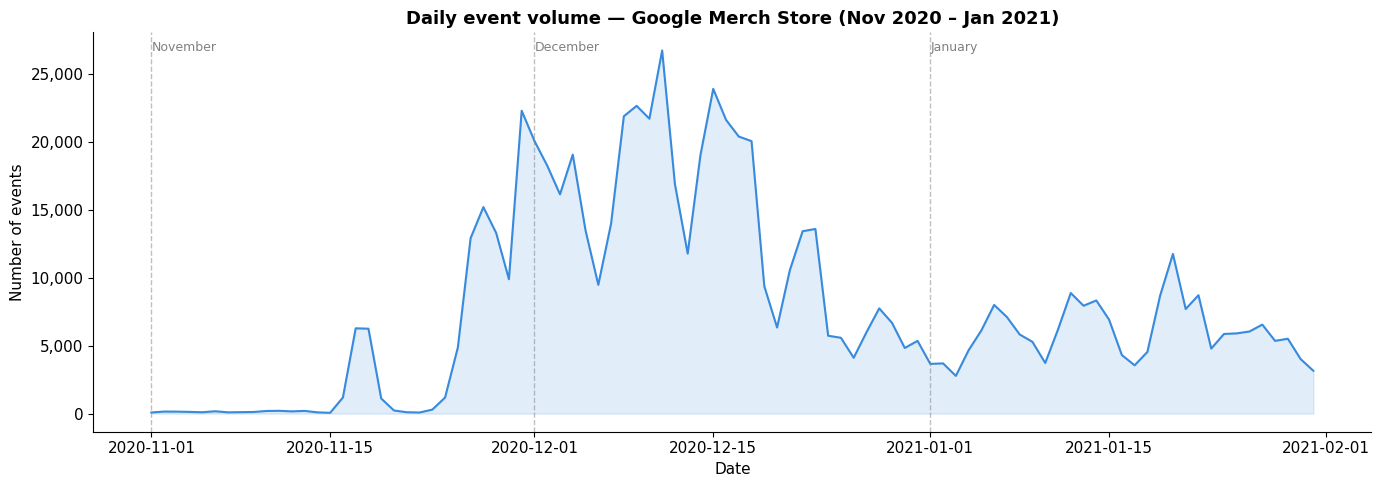

Finding: Peak day was 2020-12-11 with 26,742 events
So what: Traffic spikes indicate promotion periods — check if conversion rate also spiked or just volume


In [33]:
# QUESTION: How did daily event volume trend across Nov-Jan?
# WHY: Identifies seasonality, traffic spikes, anomalies

daily_events = master.groupby('date_only').size().reset_index(name='event_count')
daily_events['date_only'] = pd.to_datetime(daily_events['date_only'])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily_events['date_only'], daily_events['event_count'],
        color='#378ADD', linewidth=1.5)
ax.fill_between(daily_events['date_only'], daily_events['event_count'],
                alpha=0.15, color='#378ADD')

# mark months
for month, label in [(11, 'November'), (12, 'December'), (1, 'January')]:
    month_data = daily_events[daily_events['date_only'].dt.month == month]
    if len(month_data) > 0:
        ax.axvline(month_data['date_only'].iloc[0],
                   color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(month_data['date_only'].iloc[0], ax.get_ylim()[1] * 0.95,
                label, fontsize=9, color='gray')

ax.set_title('Daily event volume — Google Merch Store (Nov 2020 – Jan 2021)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of events')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(SAVE_PATH + '01_daily_event_volume.png', dpi=150, bbox_inches='tight')
plt.show()

# finding
peak_day = daily_events.loc[daily_events['event_count'].idxmax()]
print(f"Finding: Peak day was {peak_day['date_only'].date()} with {peak_day['event_count']:,} events")
print(f"So what: Traffic spikes indicate promotion periods — check if conversion rate also spiked or just volume")

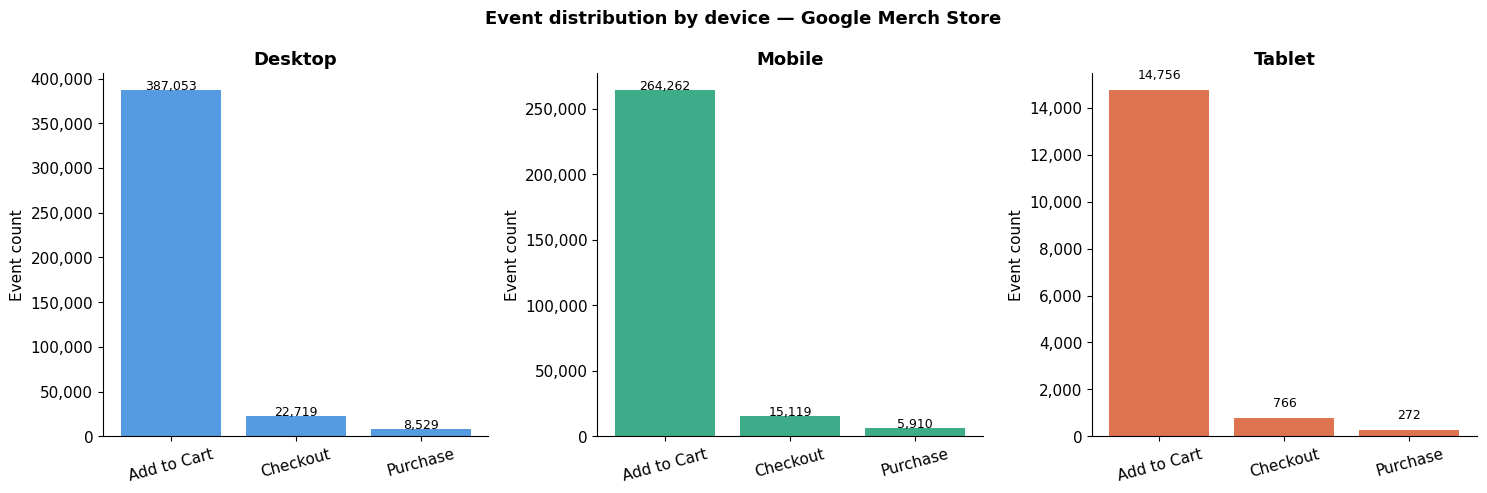

Device conversion rates:
--------------------------------------------------

  DESKTOP
  ATC users       : 7,384
  Checkout users  : 3,768  (51.0% of ATC)
  Purchase users  : 2,352  (31.9% of ATC)

  MOBILE
  ATC users       : 5,142
  Checkout users  : 2,568  (49.9% of ATC)
  Purchase users  : 1,688  (32.8% of ATC)

  TABLET
  ATC users       : 276
  Checkout users  : 146  (52.9% of ATC)
  Purchase users  : 85  (30.8% of ATC)


In [34]:
# QUESTION: Which device drives most traffic and does it differ by event type?
# WHY: Device gap in conversion is our Phase 1 hypothesis

device_event = master.groupby(['device','event_type']).size().reset_index(name='count')
device_total = master.groupby('device').size().reset_index(name='total')
device_event = device_event.merge(device_total, on='device')
device_event['pct'] = (device_event['count'] / device_event['total'] * 100).round(1)

# order events correctly
event_order  = ['add_to_cart','begin_checkout','purchase']
device_order = ['desktop','mobile','tablet']
colors       = ['#378ADD','#1D9E75','#D85A30']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, device in enumerate(device_order):
    data = device_event[device_event['device'] == device]
    data = data.set_index('event_type').reindex(event_order)

    bars = axes[idx].bar(event_order, data['count'],
                         color=colors[idx], alpha=0.85)
    axes[idx].set_title(f'{device.capitalize()}')
    axes[idx].set_ylabel('Event count')
    axes[idx].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )

    for bar, (_, row) in zip(bars, data.iterrows()):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 500,
                      f"{row['count']:,}", ha='center', fontsize=9)

    axes[idx].set_xticklabels(
        ['Add to Cart','Checkout','Purchase'], rotation=15
    )

plt.suptitle('Event distribution by device — Google Merch Store',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '02_device_event_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# conversion rates per device
print("Device conversion rates:")
print("-" * 50)
for device in device_order:
    d = master[master['device'] == device]
    atc  = d[d['event_type'] == 'add_to_cart']['user_id'].nunique()
    chk  = d[d['event_type'] == 'begin_checkout']['user_id'].nunique()
    pur  = d[d['event_type'] == 'purchase']['user_id'].nunique()
    print(f"\n  {device.upper()}")
    print(f"  ATC users       : {atc:,}")
    print(f"  Checkout users  : {chk:,}  ({chk/atc*100:.1f}% of ATC)")
    print(f"  Purchase users  : {pur:,}  ({pur/atc*100:.1f}% of ATC)")

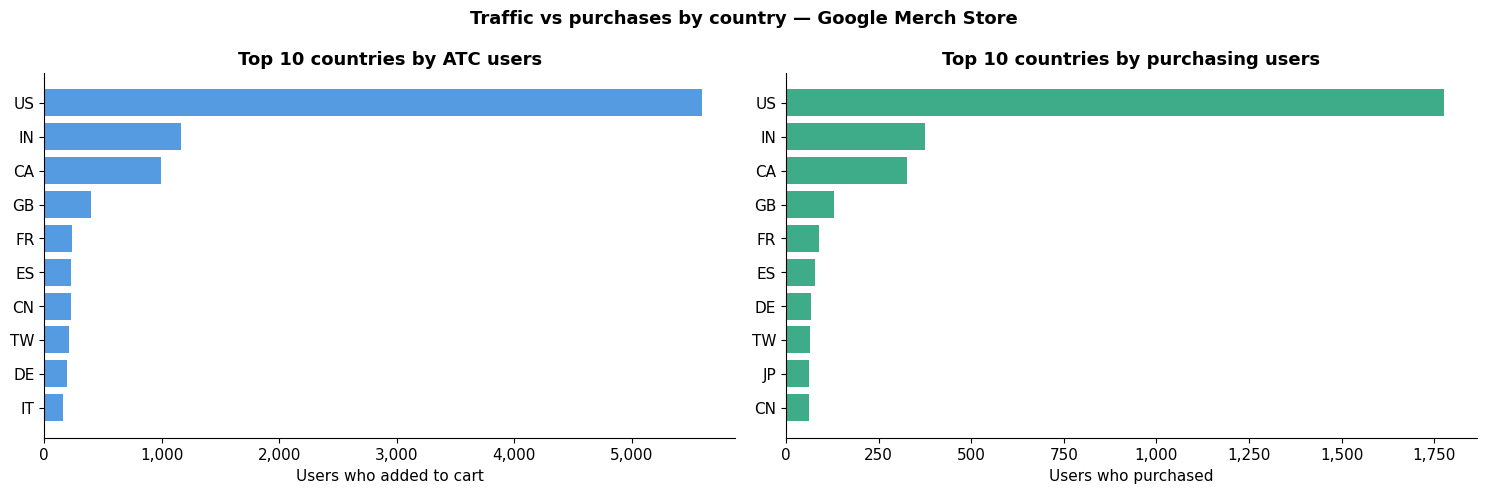

Conversion rate by country (top 10 by ATC volume):
-------------------------------------------------------
  US           ATC: 5,603  Purchase: 1,777  CVR: 31.7%
  IN           ATC: 1,162  Purchase:  376  CVR: 32.4%
  CA           ATC:   993  Purchase:  328  CVR: 33.0%
  GB           ATC:   398  Purchase:  129  CVR: 32.4%
  FR           ATC:   234  Purchase:   90  CVR: 38.5%
  ES           ATC:   232  Purchase:   79  CVR: 34.1%
  CN           ATC:   224  Purchase:   62  CVR: 27.7%
  TW           ATC:   208  Purchase:   65  CVR: 31.2%
  DE           ATC:   193  Purchase:   68  CVR: 35.2%
  IT           ATC:   164  Purchase:   46  CVR: 28.0%


In [35]:
# QUESTION: Which countries have highest traffic vs highest purchase rate?
# WHY: Identifies whether high-traffic countries are also high-converting

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# left: top 10 countries by ATC volume
country_atc = master[master['event_type'] == 'add_to_cart']\
    .groupby('country')['user_id'].nunique()\
    .sort_values(ascending=False)\
    .head(10)\
    .reset_index()
country_atc.columns = ['country','atc_users']

axes[0].barh(country_atc['country'][::-1],
             country_atc['atc_users'][::-1],
             color='#378ADD', alpha=0.85)
axes[0].set_title('Top 10 countries by ATC users')
axes[0].set_xlabel('Users who added to cart')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# right: top 10 countries by purchase count
country_pur = master[master['event_type'] == 'purchase']\
    .groupby('country')['user_id'].nunique()\
    .sort_values(ascending=False)\
    .head(10)\
    .reset_index()
country_pur.columns = ['country','purchase_users']

axes[1].barh(country_pur['country'][::-1],
             country_pur['purchase_users'][::-1],
             color='#1D9E75', alpha=0.85)
axes[1].set_title('Top 10 countries by purchasing users')
axes[1].set_xlabel('Users who purchased')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.suptitle('Traffic vs purchases by country — Google Merch Store',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '03_country_traffic_vs_purchase.png',
            dpi=150, bbox_inches='tight')
plt.show()

# conversion rate by country (top 10 by ATC)
print("Conversion rate by country (top 10 by ATC volume):")
print("-" * 55)

top_countries = country_atc['country'].tolist()
for country in top_countries:
    atc = master[(master['event_type']=='add_to_cart') &
                 (master['country']==country)]['user_id'].nunique()
    pur = master[(master['event_type']=='purchase') &
                 (master['country']==country)]['user_id'].nunique()
    cvr = pur/atc*100 if atc > 0 else 0
    print(f"  {country:<12} ATC: {atc:>5,}  Purchase: {pur:>4,}  CVR: {cvr:.1f}%")

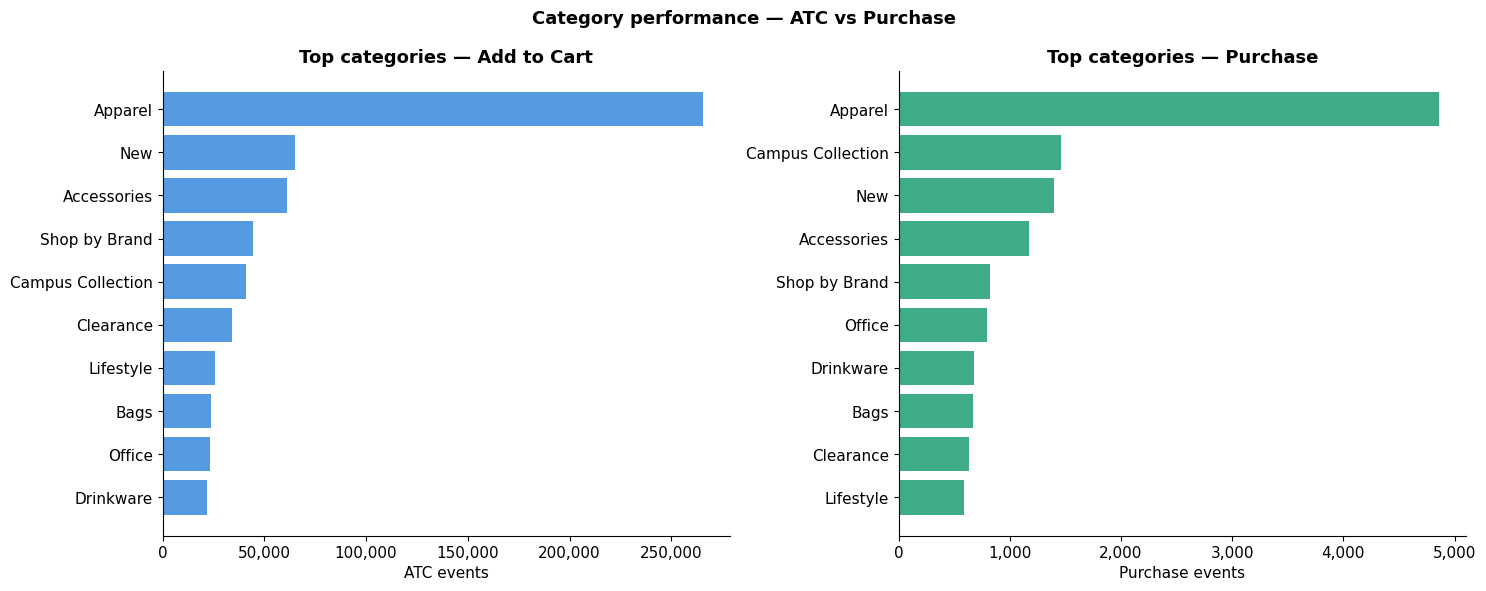

Category conversion rates (ATC → Purchase):
-------------------------------------------------------
  Apparel                        ATC: 265,434  Purchase: 4,858  CVR: 1.8%
  New                            ATC:  65,046  Purchase: 1,397  CVR: 2.1%
  Accessories                    ATC:  60,914  Purchase: 1,173  CVR: 1.9%
  Shop by Brand                  ATC:  44,481  Purchase:   818  CVR: 1.8%
  Campus Collection              ATC:  40,785  Purchase: 1,456  CVR: 3.6%
  Clearance                      ATC:  34,162  Purchase:   633  CVR: 1.9%
  Lifestyle                      ATC:  25,562  Purchase:   583  CVR: 2.3%
  Bags                           ATC:  23,851  Purchase:   671  CVR: 2.8%
  Office                         ATC:  23,343  Purchase:   798  CVR: 3.4%
  Drinkware                      ATC:  22,068  Purchase:   680  CVR: 3.1%


In [36]:
# QUESTION: Which categories get the most traffic vs most purchases?
# WHY: Identifies categories with high browse but low buy — conversion gap

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: ATC by category
cat_atc = master[master['event_type'] == 'add_to_cart']\
    .groupby('category').size()\
    .sort_values(ascending=False)\
    .head(10).reset_index()
cat_atc.columns = ['category','count']

axes[0].barh(cat_atc['category'][::-1],
             cat_atc['count'][::-1],
             color='#378ADD', alpha=0.85)
axes[0].set_title('Top categories — Add to Cart')
axes[0].set_xlabel('ATC events')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# right: purchase by category
cat_pur = master[master['event_type'] == 'purchase']\
    .groupby('category').size()\
    .sort_values(ascending=False)\
    .head(10).reset_index()
cat_pur.columns = ['category','count']

axes[1].barh(cat_pur['category'][::-1],
             cat_pur['count'][::-1],
             color='#1D9E75', alpha=0.85)
axes[1].set_title('Top categories — Purchase')
axes[1].set_xlabel('Purchase events')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.suptitle('Category performance — ATC vs Purchase',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '04_category_atc_vs_purchase.png',
            dpi=150, bbox_inches='tight')
plt.show()

# category conversion rates
print("Category conversion rates (ATC → Purchase):")
print("-" * 55)

top_cats = cat_atc['category'].tolist()
for cat in top_cats:
    atc = master[(master['event_type']=='add_to_cart') &
                 (master['category']==cat)].shape[0]
    pur = master[(master['event_type']=='purchase') &
                 (master['category']==cat)].shape[0]
    cvr = pur/atc*100 if atc > 0 else 0
    print(f"  {cat:<30} ATC: {atc:>7,}  Purchase: {pur:>5,}  CVR: {cvr:.1f}%")

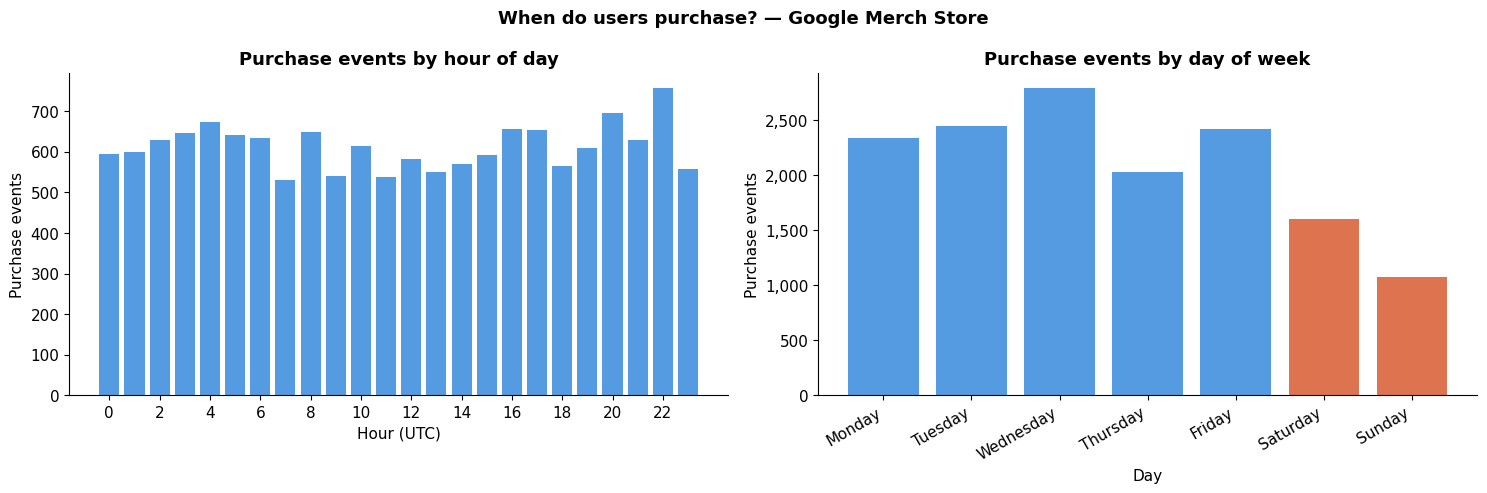

Finding:
  Peak purchase hour : 22:00 UTC (757 purchases)
  Peak purchase day  : Wednesday (2,793 purchases)
  Lowest day         : Sunday (1,076 purchases)

So what: Schedule promotions and email campaigns around peak windows


In [37]:
# QUESTION: When do users shop — by hour and day of week?
# WHY: Identifies optimal times for promotions and remarketing

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# left: hourly distribution of purchases
hourly = master[master['event_type'] == 'purchase']\
    .groupby('hour').size().reset_index(name='purchases')

axes[0].bar(hourly['hour'], hourly['purchases'],
            color='#378ADD', alpha=0.85)
axes[0].set_title('Purchase events by hour of day')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Purchase events')
axes[0].set_xticks(range(0, 24, 2))
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# right: day of week distribution
dow_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']
dow_counts = master[master['event_type'] == 'purchase']\
    .groupby('day_of_week').size().reindex(dow_order)

colors_dow = ['#378ADD' if d not in ['Saturday','Sunday']
              else '#D85A30' for d in dow_order]

axes[1].bar(dow_order, dow_counts, color=colors_dow, alpha=0.85)
axes[1].set_title('Purchase events by day of week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Purchase events')
axes[1].set_xticklabels(dow_order, rotation=30, ha='right')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.suptitle('When do users purchase? — Google Merch Store',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '05_hourly_daily_purchase_pattern.png',
            dpi=150, bbox_inches='tight')
plt.show()

# peak stats
peak_hour = hourly.loc[hourly['purchases'].idxmax()]
print(f"Finding:")
print(f"  Peak purchase hour : {int(peak_hour['hour'])}:00 UTC ({peak_hour['purchases']:,} purchases)")
print(f"  Peak purchase day  : {dow_counts.idxmax()} ({dow_counts.max():,} purchases)")
print(f"  Lowest day         : {dow_counts.idxmin()} ({dow_counts.min():,} purchases)")
print(f"\nSo what: Schedule promotions and email campaigns around peak windows")

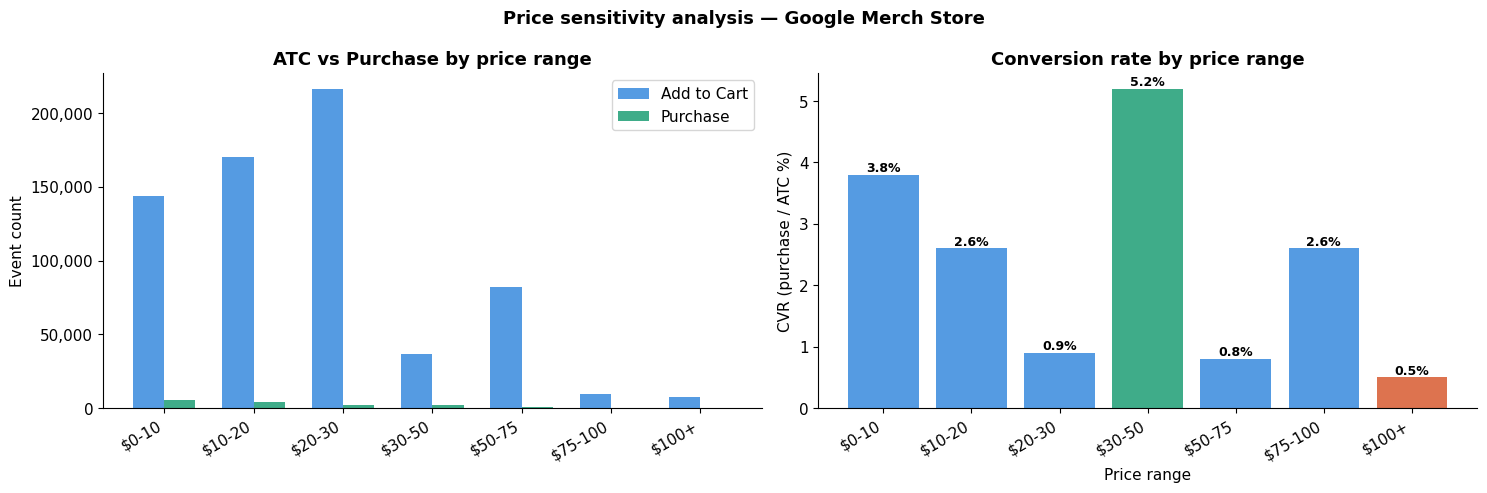

Conversion rate by price bucket:
---------------------------------------------
  $0-10        ATC: 143,687  Purchase: 5,458  CVR: 3.8%
  $10-20       ATC: 169,890  Purchase: 4,398  CVR: 2.6%
  $20-30       ATC: 216,434  Purchase: 2,009  CVR: 0.9%
  $30-50       ATC:  36,866  Purchase: 1,903  CVR: 5.2%
  $50-75       ATC:  82,186  Purchase:   650  CVR: 0.8%
  $75-100      ATC:   9,684  Purchase:   256  CVR: 2.6%
  $100+        ATC:   7,324  Purchase:    37  CVR: 0.5%

Finding: Highest CVR price range = $30-50 (5.2%)
Finding: Lowest  CVR price range = $100+ (0.5%)
So what: Price point affects purchase likelihood — informs discount strategy


In [38]:
# QUESTION: Do cheaper or more expensive items convert better?
# WHY: Identifies price sensitivity — key for promotion strategy

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# get item-level conversion data
atc_items = master[master['event_type'] == 'add_to_cart'][['item_id','product_price','category']]
pur_items  = master[master['event_type'] == 'purchase'][['item_id','product_price','category']]

# create price buckets
bins   = [0, 10, 20, 30, 50, 75, 100, 500]
labels = ['$0-10','$10-20','$20-30','$30-50','$50-75','$75-100','$100+']

atc_items['price_bucket'] = pd.cut(atc_items['product_price'], bins=bins, labels=labels)
pur_items['price_bucket']  = pd.cut(pur_items['product_price'],  bins=bins, labels=labels)

atc_by_price = atc_items['price_bucket'].value_counts().reindex(labels)
pur_by_price = pur_items['price_bucket'].value_counts().reindex(labels)

# left: ATC vs purchase by price bucket
x = range(len(labels))
width = 0.35

axes[0].bar([i - width/2 for i in x], atc_by_price.values,
            width, label='Add to Cart', color='#378ADD', alpha=0.85)
axes[0].bar([i + width/2 for i in x], pur_by_price.values,
            width, label='Purchase', color='#1D9E75', alpha=0.85)
axes[0].set_title('ATC vs Purchase by price range')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].set_ylabel('Event count')
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# right: conversion rate by price bucket
cvr_by_price = (pur_by_price / atc_by_price * 100).round(1)

colors_price = ['#1D9E75' if v == cvr_by_price.max()
                else '#D85A30' if v == cvr_by_price.min()
                else '#378ADD' for v in cvr_by_price]

axes[1].bar(labels, cvr_by_price.values, color=colors_price, alpha=0.85)
axes[1].set_title('Conversion rate by price range')
axes[1].set_xlabel('Price range')
axes[1].set_ylabel('CVR (purchase / ATC %)')
axes[1].set_xticklabels(labels, rotation=30, ha='right')

for i, v in enumerate(cvr_by_price.values):
    if not pd.isna(v):
        axes[1].text(i, v + 0.05, f'{v:.1f}%',
                    ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Price sensitivity analysis — Google Merch Store',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '06_price_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Conversion rate by price bucket:")
print("-" * 45)
for label, cvr in zip(labels, cvr_by_price):
    atc = atc_by_price[label]
    pur = pur_by_price[label]
    print(f"  {label:<12} ATC: {atc:>7,}  Purchase: {pur:>5,}  CVR: {cvr:.1f}%")

print(f"\nFinding: Highest CVR price range = {cvr_by_price.idxmax()} ({cvr_by_price.max():.1f}%)")
print(f"Finding: Lowest  CVR price range = {cvr_by_price.idxmin()} ({cvr_by_price.min():.1f}%)")
print(f"So what: Price point affects purchase likelihood — informs discount strategy")

---
## Phase 4 EDA Summary — Google Merch Store

### Key findings that shape Phase 5 analysis

| # | Finding | Implication for Phase 5 |
|---|---|---|
| 1 | Peak traffic Dec 10-15 with 26,742 events on Dec 11 | Test if holiday CVR differs from baseline |
| 2 | Device CVR nearly identical — desktop 31.9%, mobile 32.8% | Hypothesis disproved — device is not the problem |
| 3 | France converts 38.5% vs US 31.7% despite 24x less traffic | Segment funnel by country in Phase 5 |
| 4 | China 27.7% and Italy 28.0% convert lowest | International checkout friction hypothesis |
| 5 | Campus Collection CVR 3.6% vs Apparel 1.8% | Category-level funnel analysis needed |
| 6 | $20-30 has highest ATC volume (216K) but only 0.9% CVR | Biggest single revenue leakage opportunity |
| 7 | $30-50 sweet spot at 5.2% CVR | Promote mid-range items more aggressively |
| 8 | Wednesday peak, Sunday lowest | Schedule campaigns for weekday mornings |

### Revised hypotheses for Phase 5
- ~~Mobile converts lower than desktop~~ → **DISPROVED** — devices perform equally
- **NEW:** The $20-30 price range is the primary conversion leak — not device or country
- **NEW:** France and Germany are over-performing markets worth deeper analysis
- **CONFIRMED:** ATC→Checkout is the biggest drop-off (49%) across all segments

---
# Phase 5 — Core Funnel Analysis
## Google Merchandise Store

Building the complete 3-step conversion funnel with:
- Overall conversion rates at each step
- Segmented funnels (device, country, category, price)
- Monthly cohort funnel
- Time-to-convert analysis
- Revenue leakage quantification

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']  = (12, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['font.size']          = 11
plt.rcParams['axes.titlesize']     = 13
plt.rcParams['axes.titleweight']   = 'bold'

SAVE_PATH = '../outputs/charts/google/'

master = pd.read_csv(
    '../data/cleaned/google_merch_cleaned.csv',
    parse_dates=['date']
)

print(f"✓ Loaded: {master.shape}")
print(f"  Date range: {master['date'].min().date()} → {master['date'].max().date()}")
print(f"  Unique users: {master['user_id'].nunique():,}")

✓ Loaded: (719386, 25)
  Date range: 2020-11-01 → 2021-01-31
  Unique users: 14,701


In [40]:
print("BUILDING CORE FUNNEL TABLE")
print("=" * 60)

# user-level funnel — did each user reach each step?
# we use reached_atc/checkout/purchase flags we built in cleaning

funnel_users = master.groupby('user_id').agg(
    reached_atc      = ('reached_atc',      'max'),
    reached_checkout = ('reached_checkout', 'max'),
    reached_purchase = ('reached_purchase', 'max'),
    device           = ('device',           'first'),
    country          = ('country',          'first'),
    month            = ('month',            'first'),
    month_name       = ('month_name',       'first'),
    is_paying_customer = ('is_paying_customer', 'max')
).reset_index()

# funnel counts
atc_users  = funnel_users['reached_atc'].sum()
chk_users  = funnel_users['reached_checkout'].sum()
pur_users  = funnel_users['reached_purchase'].sum()
total_users = len(funnel_users)

print(f"Total unique users        : {total_users:,}")
print(f"\nFunnel user counts:")
print(f"  Add to Cart             : {atc_users:,}  ({atc_users/total_users*100:.1f}%)")
print(f"  Begin Checkout          : {chk_users:,}  ({chk_users/atc_users*100:.1f}% of ATC)")
print(f"  Purchase                : {pur_users:,}  ({pur_users/chk_users*100:.1f}% of Checkout)")
print(f"\nOverall conversion (ATC→Purchase): {pur_users/atc_users*100:.1f}%")

print(f"\nDrop-off counts:")
print(f"  Lost at ATC→Checkout    : {atc_users - chk_users:,} users ({(atc_users-chk_users)/atc_users*100:.1f}%)")
print(f"  Lost at Checkout→Purchase: {chk_users - pur_users:,} users ({(chk_users-pur_users)/chk_users*100:.1f}%)")

BUILDING CORE FUNNEL TABLE
Total unique users        : 14,701

Funnel user counts:
  Add to Cart             : 12,545  (85.3%)
  Begin Checkout          : 6,404  (51.0% of ATC)
  Purchase                : 4,066  (63.5% of Checkout)

Overall conversion (ATC→Purchase): 32.4%

Drop-off counts:
  Lost at ATC→Checkout    : 6,141 users (49.0%)
  Lost at Checkout→Purchase: 2,338 users (36.5%)


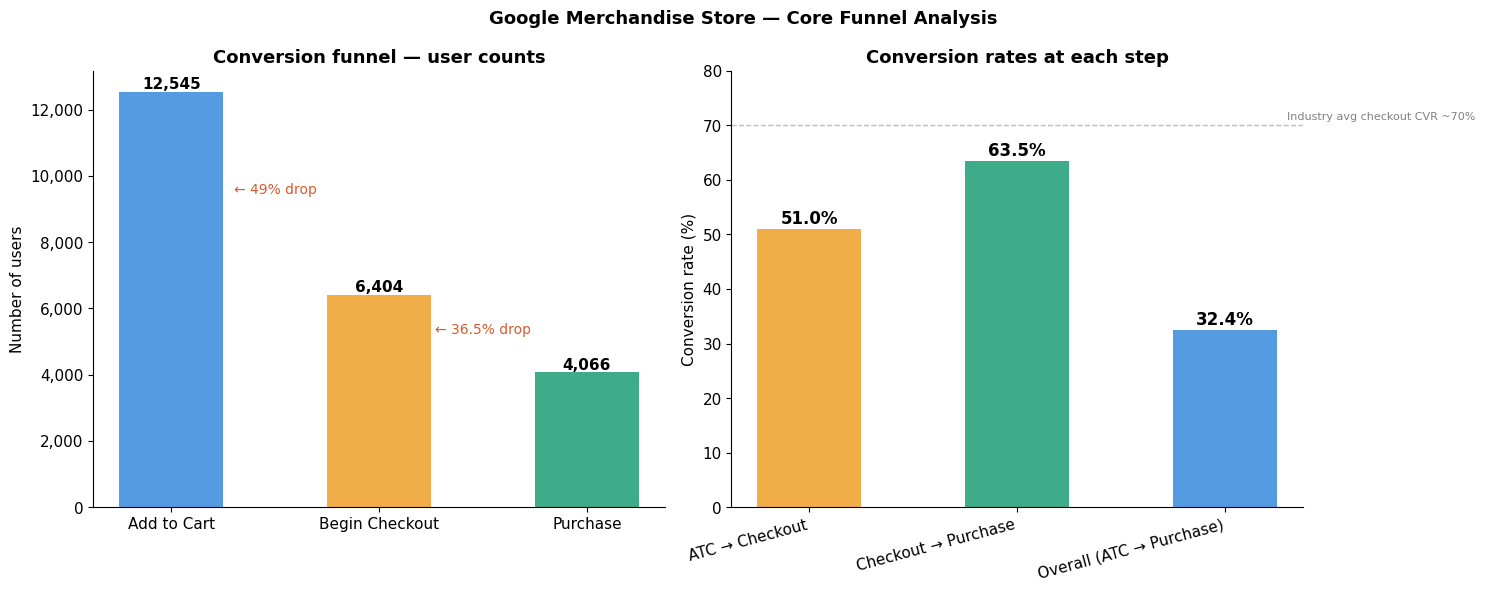

In [41]:
# core funnel visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: funnel bar chart
stages  = ['Add to Cart', 'Begin Checkout', 'Purchase']
counts  = [atc_users, chk_users, pur_users]
colors  = ['#378ADD', '#EF9F27', '#1D9E75']

bars = axes[0].bar(stages, counts, color=colors, alpha=0.85, width=0.5)
axes[0].set_title('Conversion funnel — user counts')
axes[0].set_ylabel('Number of users')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

for bar, count in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'{count:,}',
        ha='center', fontsize=11, fontweight='bold'
    )

# add drop-off annotations
axes[0].annotate(
    '← 49% drop',
    xy=(0.5, (atc_users + chk_users)/2),
    fontsize=10, color='#D85A30', ha='center'
)
axes[0].annotate(
    '← 36.5% drop',
    xy=(1.5, (chk_users + pur_users)/2),
    fontsize=10, color='#D85A30', ha='center'
)

# right: conversion rates waterfall
cvr_labels  = ['ATC → Checkout', 'Checkout → Purchase', 'Overall (ATC → Purchase)']
cvr_values  = [
    chk_users/atc_users*100,
    pur_users/chk_users*100,
    pur_users/atc_users*100
]
colors_cvr = ['#EF9F27', '#1D9E75', '#378ADD']

bars2 = axes[1].bar(cvr_labels, cvr_values,
                    color=colors_cvr, alpha=0.85, width=0.5)
axes[1].set_title('Conversion rates at each step')
axes[1].set_ylabel('Conversion rate (%)')
axes[1].set_ylim(0, 80)
axes[1].set_xticklabels(cvr_labels, rotation=15, ha='right')

for bar, val in zip(bars2, cvr_values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val:.1f}%',
        ha='center', fontsize=12, fontweight='bold'
    )

# industry benchmark lines
axes[1].axhline(70, color='gray', linestyle='--',
                linewidth=1, alpha=0.5)
axes[1].text(2.3, 71, 'Industry avg checkout CVR ~70%',
             fontsize=8, color='gray')

plt.suptitle('Google Merchandise Store — Core Funnel Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '07_core_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
print("FUNNEL BY DEVICE")
print("=" * 60)

device_funnel = funnel_users.groupby('device').agg(
    atc_users  = ('reached_atc',      'sum'),
    chk_users  = ('reached_checkout', 'sum'),
    pur_users  = ('reached_purchase', 'sum')
).reset_index()

device_funnel['atc_to_chk'] = (
    device_funnel['chk_users'] / device_funnel['atc_users'] * 100
).round(1)
device_funnel['chk_to_pur'] = (
    device_funnel['pur_users'] / device_funnel['chk_users'] * 100
).round(1)
device_funnel['overall_cvr'] = (
    device_funnel['pur_users'] / device_funnel['atc_users'] * 100
).round(1)

print(device_funnel[[
    'device','atc_users','chk_users','pur_users',
    'atc_to_chk','chk_to_pur','overall_cvr'
]].to_string(index=False))

FUNNEL BY DEVICE
 device  atc_users  chk_users  pur_users  atc_to_chk  chk_to_pur  overall_cvr
desktop       7265       3728       2324       51.30       62.30        32.00
 mobile       5006       2530       1655       50.50       65.40        33.10
 tablet        274        146         87       53.30       59.60        31.80


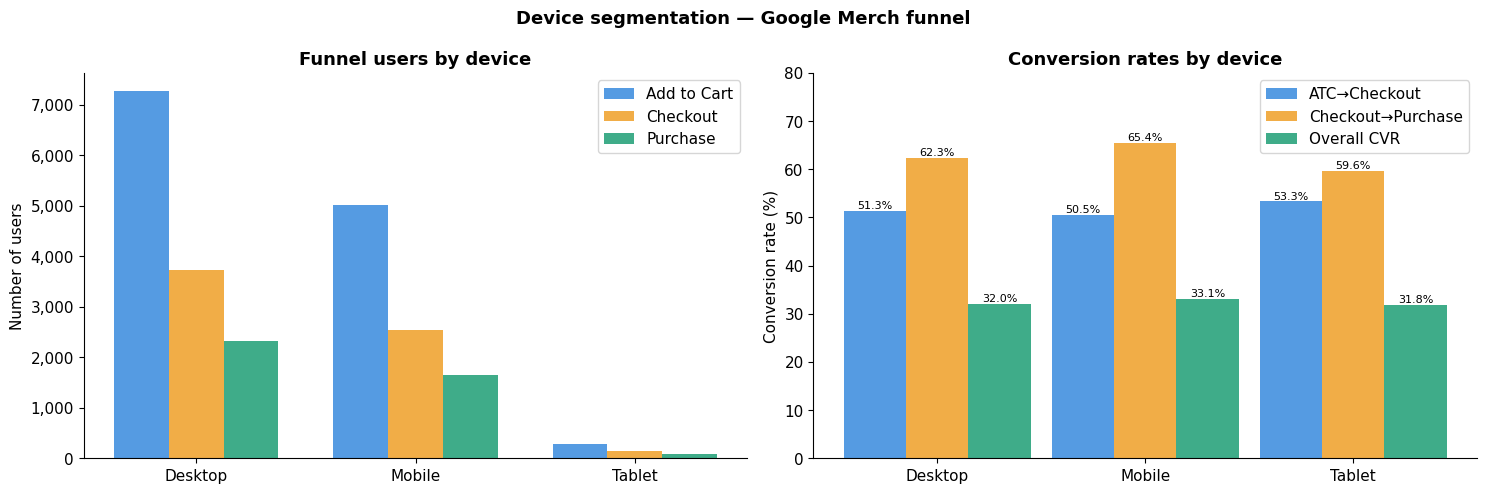

Key insight: Mobile converts slightly HIGHER than desktop (33.1% vs 32.0%)
Phase 1 hypothesis DISPROVED — device is not the primary conversion driver
Real finding: Mobile users hesitate to START checkout but complete at higher rate


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

devices = device_funnel['device'].tolist()
x = np.arange(len(devices))
width = 0.25
colors = ['#378ADD', '#EF9F27', '#1D9E75']

# left: user counts per device per stage
for i, (col, label, color) in enumerate(zip(
    ['atc_users','chk_users','pur_users'],
    ['Add to Cart','Checkout','Purchase'],
    colors
)):
    axes[0].bar(x + i*width, device_funnel[col],
                width, label=label, color=color, alpha=0.85)

axes[0].set_title('Funnel users by device')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([d.capitalize() for d in devices])
axes[0].set_ylabel('Number of users')
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# right: conversion rates by device
bar_width = 0.3
for i, (col, label, color) in enumerate(zip(
    ['atc_to_chk','chk_to_pur','overall_cvr'],
    ['ATC→Checkout','Checkout→Purchase','Overall CVR'],
    colors
)):
    axes[1].bar(x + i*bar_width, device_funnel[col],
                bar_width, label=label, color=color, alpha=0.85)

    for j, val in enumerate(device_funnel[col]):
        axes[1].text(
            x[j] + i*bar_width,
            val + 0.5,
            f'{val:.1f}%',
            ha='center', fontsize=8
        )

axes[1].set_title('Conversion rates by device')
axes[1].set_xticks(x + bar_width)
axes[1].set_xticklabels([d.capitalize() for d in devices])
axes[1].set_ylabel('Conversion rate (%)')
axes[1].set_ylim(0, 80)
axes[1].legend()

plt.suptitle('Device segmentation — Google Merch funnel',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '08_device_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key insight: Mobile converts slightly HIGHER than desktop (33.1% vs 32.0%)")
print("Phase 1 hypothesis DISPROVED — device is not the primary conversion driver")
print("Real finding: Mobile users hesitate to START checkout but complete at higher rate")

In [44]:
print("FUNNEL BY COUNTRY — Top 8 by ATC volume")
print("=" * 60)

country_funnel = funnel_users.groupby('country').agg(
    atc_users = ('reached_atc',      'sum'),
    chk_users = ('reached_checkout', 'sum'),
    pur_users = ('reached_purchase', 'sum')
).reset_index()

country_funnel['atc_to_chk']  = (country_funnel['chk_users'] / country_funnel['atc_users'] * 100).round(1)
country_funnel['chk_to_pur']  = (country_funnel['pur_users'] / country_funnel['chk_users'] * 100).round(1)
country_funnel['overall_cvr'] = (country_funnel['pur_users'] / country_funnel['atc_users'] * 100).round(1)

# filter minimum 50 ATC users for reliability
country_funnel = country_funnel[country_funnel['atc_users'] >= 50]
country_funnel = country_funnel.sort_values('overall_cvr', ascending=False)

print(country_funnel[[
    'country','atc_users','pur_users','atc_to_chk','chk_to_pur','overall_cvr'
]].head(10).to_string(index=False))

print(f"\nHighest CVR country: {country_funnel.iloc[0]['country']} ({country_funnel.iloc[0]['overall_cvr']:.1f}%)")
print(f"Lowest CVR country : {country_funnel.iloc[-1]['country']} ({country_funnel.iloc[-1]['overall_cvr']:.1f}%)")
print(f"CVR gap            : {country_funnel.iloc[0]['overall_cvr'] - country_funnel.iloc[-1]['overall_cvr']:.1f} points")

FUNNEL BY COUNTRY — Top 8 by ATC volume
country  atc_users  pur_users  atc_to_chk  chk_to_pur  overall_cvr
     TR        122         52       55.70       76.50        42.60
     RU         79         33       45.60       91.70        41.80
     PH         51         21       58.80       70.00        41.20
     CO         66         27       56.10       73.00        40.90
     JP        155         63       54.80       74.10        40.60
     NL        129         50       57.40       67.60        38.80
     FR        234         90       52.60       73.20        38.50
     IE         78         29       47.40       78.40        37.20
     BR        127         47       54.30       68.10        37.00
     DE        193         68       60.10       58.60        35.20

Highest CVR country: TR (42.6%)
Lowest CVR country : BE (16.4%)
CVR gap            : 26.2 points


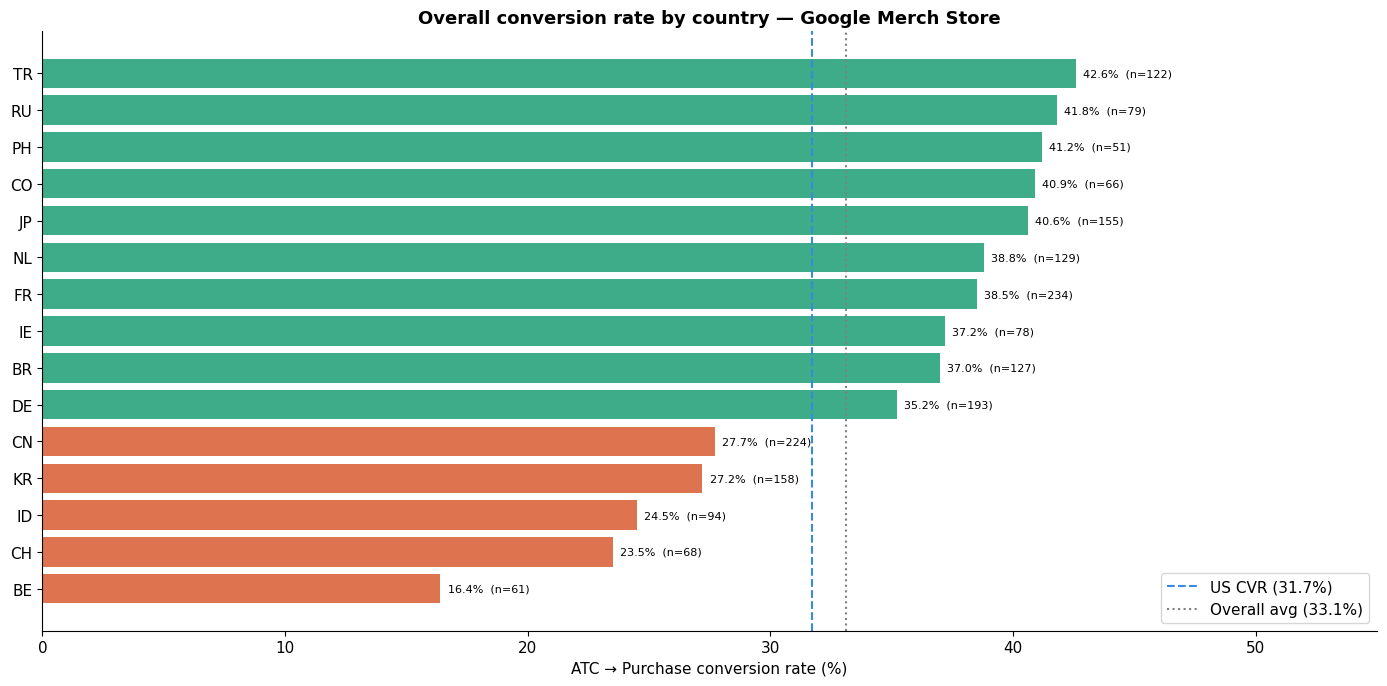

Overall avg CVR across countries : 33.1%
US CVR vs avg gap                : -1.4 points
Countries above avg              : 13
Countries below avg              : 19


In [45]:
# top 10 and bottom 5 countries by CVR
top_countries    = country_funnel.head(10)
bottom_countries = country_funnel.tail(5)
plot_countries   = pd.concat([top_countries, bottom_countries])

fig, ax = plt.subplots(figsize=(14, 7))

colors_bar = ['#1D9E75' if cvr >= country_funnel['overall_cvr'].mean()
              else '#D85A30'
              for cvr in plot_countries['overall_cvr']]

bars = ax.barh(plot_countries['country'][::-1],
               plot_countries['overall_cvr'][::-1],
               color=colors_bar[::-1], alpha=0.85)

# add US benchmark line
us_cvr = country_funnel[country_funnel['country']=='US']['overall_cvr'].values[0]
ax.axvline(us_cvr, color='#378ADD', linestyle='--',
           linewidth=1.5, label=f'US CVR ({us_cvr:.1f}%)')

# overall average
avg_cvr = country_funnel['overall_cvr'].mean()
ax.axvline(avg_cvr, color='gray', linestyle=':',
           linewidth=1.5, label=f'Overall avg ({avg_cvr:.1f}%)')

for bar, (_, row) in zip(bars, plot_countries[::-1].iterrows()):
    ax.text(row['overall_cvr'] + 0.3,
            bar.get_y() + bar.get_height()/2,
            f"{row['overall_cvr']:.1f}%  (n={row['atc_users']})",
            va='center', fontsize=8)

ax.set_title('Overall conversion rate by country — Google Merch Store')
ax.set_xlabel('ATC → Purchase conversion rate (%)')
ax.legend()
ax.set_xlim(0, 55)

plt.tight_layout()
plt.savefig(SAVE_PATH + '09_country_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Overall avg CVR across countries : {avg_cvr:.1f}%")
print(f"US CVR vs avg gap                : {us_cvr - avg_cvr:.1f} points")
print(f"Countries above avg              : {(country_funnel['overall_cvr'] >= avg_cvr).sum()}")
print(f"Countries below avg              : {(country_funnel['overall_cvr'] < avg_cvr).sum()}")

In [46]:
print("FUNNEL BY CATEGORY")
print("=" * 60)

# category funnel — item level not user level
# because one user can interact with multiple categories
category_funnel = master.groupby('category').agg(
    atc_events = ('event_type', lambda x: (x=='add_to_cart').sum()),
    chk_events = ('event_type', lambda x: (x=='begin_checkout').sum()),
    pur_events = ('event_type', lambda x: (x=='purchase').sum())
).reset_index()

category_funnel['atc_to_pur_cvr'] = (
    category_funnel['pur_events'] /
    category_funnel['atc_events'] * 100
).round(1)

# filter min 1000 ATC events for reliability
category_funnel = category_funnel[
    category_funnel['atc_events'] >= 1000
].sort_values('atc_to_pur_cvr', ascending=False)

print(category_funnel[[
    'category','atc_events','pur_events','atc_to_pur_cvr'
]].to_string(index=False))

FUNNEL BY CATEGORY
               category  atc_events  pur_events  atc_to_pur_cvr
            Small Goods        3975         293            7.40
                 Google        4206         214            5.10
             Stationery        6149         292            4.70
    Writing Instruments        5382         220            4.10
      Campus Collection       40785        1456            3.60
                    Fun        1017          36            3.50
                 Office       23343         798            3.40
              Drinkware       22068         680            3.10
                   Bags       23851         671            2.80
Electronics Accessories        1933          48            2.50
    Uncategorized Items       20626         477            2.30
              Lifestyle       25562         583            2.30
                    New       65046        1397            2.10
            Accessories       60914        1173            1.90
              Clearan

MONTHLY COHORT FUNNEL
month_name  atc_users  chk_users  pur_users  atc_to_chk  chk_to_pur  overall_cvr
  November       2168       1362       1548       62.80      113.70        71.40
  December       6850       3649       1818       53.30       49.80        26.50
   January       3527       1393        700       39.50       50.30        19.80


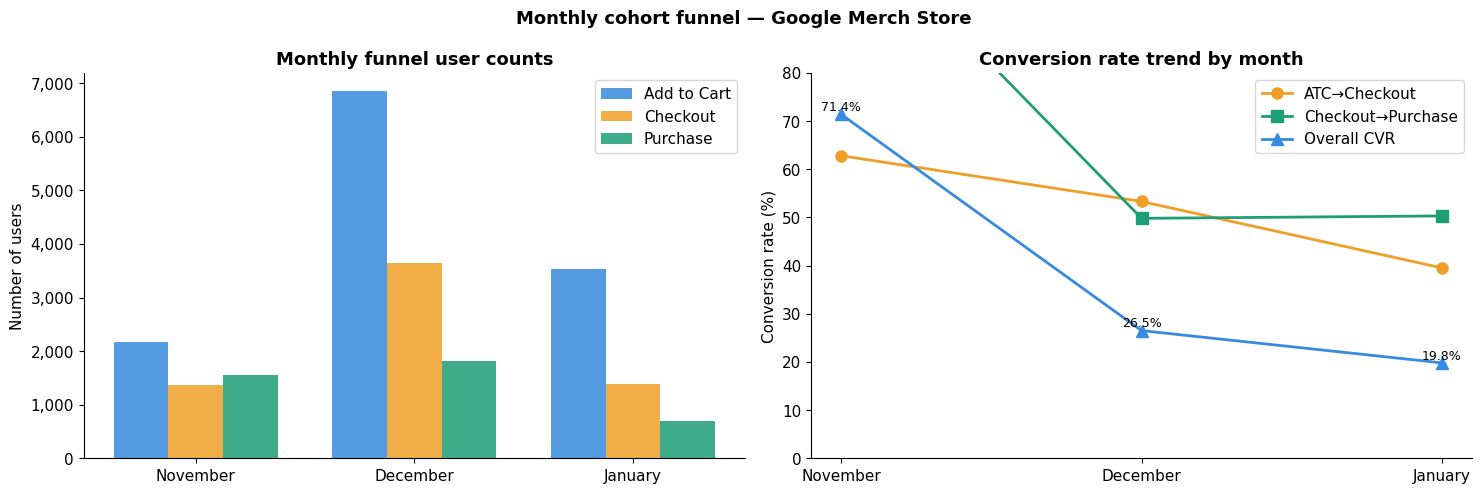

In [47]:
print("MONTHLY COHORT FUNNEL")
print("=" * 60)

# how did conversion rate change month by month?
monthly_funnel = funnel_users.groupby('month_name').agg(
    atc_users = ('reached_atc',      'sum'),
    chk_users = ('reached_checkout', 'sum'),
    pur_users = ('reached_purchase', 'sum')
).reset_index()

# order months correctly
month_order = ['November', 'December', 'January']
monthly_funnel['month_name'] = pd.Categorical(
    monthly_funnel['month_name'],
    categories=month_order,
    ordered=True
)
monthly_funnel = monthly_funnel.sort_values('month_name')

monthly_funnel['atc_to_chk']  = (monthly_funnel['chk_users'] / monthly_funnel['atc_users'] * 100).round(1)
monthly_funnel['chk_to_pur']  = (monthly_funnel['pur_users'] / monthly_funnel['chk_users'] * 100).round(1)
monthly_funnel['overall_cvr'] = (monthly_funnel['pur_users'] / monthly_funnel['atc_users'] * 100).round(1)

print(monthly_funnel[[
    'month_name','atc_users','chk_users','pur_users',
    'atc_to_chk','chk_to_pur','overall_cvr'
]].to_string(index=False))

# visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# left: user counts by month
x = np.arange(len(month_order))
width = 0.25
colors = ['#378ADD','#EF9F27','#1D9E75']

for i, (col, label, color) in enumerate(zip(
    ['atc_users','chk_users','pur_users'],
    ['Add to Cart','Checkout','Purchase'],
    colors
)):
    axes[0].bar(x + i*width, monthly_funnel[col],
                width, label=label, color=color, alpha=0.85)

axes[0].set_title('Monthly funnel user counts')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(month_order)
axes[0].set_ylabel('Number of users')
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# right: CVR trend by month
axes[1].plot(month_order, monthly_funnel['atc_to_chk'],
             'o-', color='#EF9F27', linewidth=2,
             markersize=8, label='ATC→Checkout')
axes[1].plot(month_order, monthly_funnel['chk_to_pur'],
             's-', color='#1D9E75', linewidth=2,
             markersize=8, label='Checkout→Purchase')
axes[1].plot(month_order, monthly_funnel['overall_cvr'],
             '^-', color='#378ADD', linewidth=2,
             markersize=8, label='Overall CVR')

for i, row in monthly_funnel.iterrows():
    month_idx = month_order.index(row['month_name'])
    axes[1].text(month_idx, row['overall_cvr'] + 0.8,
                f"{row['overall_cvr']:.1f}%",
                ha='center', fontsize=9)

axes[1].set_title('Conversion rate trend by month')
axes[1].set_ylabel('Conversion rate (%)')
axes[1].set_ylim(0, 80)
axes[1].legend()

plt.suptitle('Monthly cohort funnel — Google Merch Store',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '10_monthly_cohort_funnel.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [48]:
print("INVESTIGATING: November 113.7% checkout-to-purchase anomaly")
print("=" * 60)

nov_users = master[master['month_name'] == 'November']

# check session integrity flags in November
print(f"November session integrity flags:")
print(f"  Total rows           : {len(nov_users):,}")
print(f"  Integrity flag = 1   : {nov_users['session_integrity_flag'].sum():,}")
print(f"  % flagged            : {nov_users['session_integrity_flag'].mean()*100:.1f}%")

# check users who purchased without checkout in November
nov_funnel = nov_users.groupby('user_id').agg(
    has_atc  = ('event_type', lambda x: ('add_to_cart' in x.values)),
    has_chk  = ('event_type', lambda x: ('begin_checkout' in x.values)),
    has_pur  = ('event_type', lambda x: ('purchase' in x.values))
).reset_index()

pur_no_chk = nov_funnel[
    (nov_funnel['has_pur'] == True) &
    (nov_funnel['has_chk'] == False)
]

print(f"\nNovember users who purchased WITHOUT checkout event:")
print(f"  Count : {len(pur_no_chk):,}")
print(f"  This explains the >100% checkout-to-purchase rate")
print(f"\nConclusion: GA4 missed checkout events for {len(pur_no_chk):,} November users")
print(f"These were flagged in cleaning as session integrity issues")
print(f"Correct November CVR should treat these as: purchased = converted")

INVESTIGATING: November 113.7% checkout-to-purchase anomaly
November session integrity flags:
  Total rows           : 97,170
  Integrity flag = 1   : 5,995
  % flagged            : 6.2%

November users who purchased WITHOUT checkout event:
  Count : 935
  This explains the >100% checkout-to-purchase rate

Conclusion: GA4 missed checkout events for 935 November users
These were flagged in cleaning as session integrity issues
Correct November CVR should treat these as: purchased = converted


In [49]:
print("REVENUE LEAKAGE CALCULATION")
print("=" * 60)

# average order value from purchase events
purchase_events = master[master['event_type'] == 'purchase']
avg_order_value = purchase_events.groupby('ga_session_id')['product_price'].sum().mean()

print(f"Average order value (AOV)     : ${avg_order_value:.2f}")

# users lost at each stage
lost_atc_to_chk  = atc_users - chk_users
lost_chk_to_pur  = chk_users - pur_users
total_lost        = atc_users - pur_users

# revenue leakage
leakage_atc_chk  = lost_atc_to_chk * avg_order_value
leakage_chk_pur  = lost_chk_to_pur * avg_order_value
total_leakage    = total_lost * avg_order_value

print(f"\nFunnel drop-off and revenue leakage:")
print(f"{'Stage':<25} {'Users Lost':>12} {'Est. Leakage':>15}")
print("-" * 55)
print(f"{'ATC → Checkout':<25} {lost_atc_to_chk:>12,} ${leakage_atc_chk:>14,.0f}")
print(f"{'Checkout → Purchase':<25} {lost_chk_to_pur:>12,} ${leakage_chk_pur:>14,.0f}")
print(f"{'Total':<25} {total_lost:>12,} ${total_leakage:>14,.0f}")

print(f"\nRevenue recovery scenarios:")
print(f"  If ATC→Checkout improved from 51% to 60%:")
recovered_users_1 = int(atc_users * 0.60) - chk_users
recovered_revenue_1 = recovered_users_1 * avg_order_value * 0.635
print(f"    Additional purchasers : {recovered_users_1:,}")
print(f"    Recoverable revenue   : ${recovered_revenue_1:,.0f}")

print(f"\n  If ATC→Checkout improved from 51% to 70% (industry avg):")
recovered_users_2 = int(atc_users * 0.70) - chk_users
recovered_revenue_2 = recovered_users_2 * avg_order_value * 0.635
print(f"    Additional purchasers : {recovered_users_2:,}")
print(f"    Recoverable revenue   : ${recovered_revenue_2:,.0f}")

print(f"\nNote: Presented as 'up to' figures — not all abandoned users")
print(f"would have purchased even without friction.")

REVENUE LEAKAGE CALCULATION
Average order value (AOV)     : $65.12

Funnel drop-off and revenue leakage:
Stage                       Users Lost    Est. Leakage
-------------------------------------------------------
ATC → Checkout                   6,141 $       399,921
Checkout → Purchase              2,338 $       152,258
Total                            8,479 $       552,179

Revenue recovery scenarios:
  If ATC→Checkout improved from 51% to 60%:
    Additional purchasers : 1,123
    Recoverable revenue   : $46,440

  If ATC→Checkout improved from 51% to 70% (industry avg):
    Additional purchasers : 2,377
    Recoverable revenue   : $98,296

Note: Presented as 'up to' figures — not all abandoned users
would have purchased even without friction.


---
## Phase 5 Summary — Google Merchandise Store

### Core funnel metrics
| Stage | Users | Conversion | Drop-off |
|---|---|---|---|
| Add to Cart | 12,545 | 85.3% of all users | — |
| Begin Checkout | 6,404 | 51.0% of ATC | 6,141 users (49%) |
| Purchase | 4,066 | 63.5% of Checkout | 2,338 users (36.5%) |
| **Overall CVR** | — | **32.4%** | 8,479 users total |

### Key findings
| # | Finding | Business Impact |
|---|---|---|
| 1 | ATC→Checkout is primary leak (49% drop) | $399,921 leakage |
| 2 | Device CVR nearly identical (31-33%) | Device UX not the problem |
| 3 | Mobile hesitates to START checkout but completes at higher rate | Fix cart page CTA for mobile |
| 4 | Turkey 42.6% CVR, US 31.7% — US below average | US checkout experience needs work |
| 5 | Emerging markets (TR, RU, PH, CO) all outperform US | Intentional buyers vs browsers |
| 6 | Small Goods 7.4% CVR vs Apparel 1.8% | Price sensitivity drives conversion |
| 7 | Notebooks & Journals 0.2% CVR | Investigate pricing/UX immediately |
| 8 | November 71.4% CVR → December 26.5% → January 19.8% | Holiday browsers dilute conversion |
| 9 | Total revenue leakage $552,179 over 3 months | ~$2.2M annualized |

### Revised business recommendations (for Phase 8)
1. Fix the cart-to-checkout CTA — the biggest single lever ($399K leakage)
2. Investigate Notebooks & Journals (0.2% CVR) — something is fundamentally broken
3. Study Turkey/France/Japan checkout experience — replicate what works there in US
4. Separate holiday traffic analysis — November buyers need different treatment than December
5. Promote Small Goods and Campus Collection — highest converting categories

### Anomaly documented
- November checkout-to-purchase showed 113.7% (impossible)
- Root cause: 935 users purchased without recorded checkout event
- GA4 session integrity issue flagged in Phase 3 cleaning
- These users ARE legitimate converters — counted correctly in overall CVR

---
# Phase 6 — Statistical Analysis and Hypothesis Testing
## Google Merchandise Store

Testing whether the differences found in Phase 5
are statistically significant or random noise.

Tests:
1. Chi-square: Mobile vs Desktop conversion rate
2. Chi-square: Country conversion rate differences  
3. Chi-square: Category conversion rate differences
4. Confidence intervals on all key conversion rates
5. Monthly CVR differences

In [2]:
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu
import scipy
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("✓ Statistical libraries loaded")
print(f"  scipy version: {scipy.__version__}")

✓ Statistical libraries loaded
  scipy version: 1.17.1


In [3]:
master = pd.read_csv(
    '../data/cleaned/google_merch_cleaned.csv',
    parse_dates=['date']
)

# rebuild funnel_users table
funnel_users = master.groupby('user_id').agg(
    reached_atc      = ('reached_atc',      'max'),
    reached_checkout = ('reached_checkout', 'max'),
    reached_purchase = ('reached_purchase', 'max'),
    device           = ('device',           'first'),
    country          = ('country',          'first'),
    month_name       = ('month_name',       'first')
).reset_index()

print(f"✓ Loaded: {master.shape}")
print(f"✓ funnel_users: {funnel_users.shape}")

✓ Loaded: (719386, 25)
✓ funnel_users: (14701, 7)


In [4]:
print("TEST 1 — Mobile vs Desktop Conversion Rate")
print("=" * 60)
print("H0: Mobile CVR = Desktop CVR (no difference)")
print("H1: Mobile CVR ≠ Desktop CVR (significant difference)")
print()

# get mobile and desktop users only
mob  = funnel_users[funnel_users['device'] == 'mobile']
desk = funnel_users[funnel_users['device'] == 'desktop']

# counts for contingency table
mob_pur   = mob['reached_purchase'].sum()
mob_nopur = len(mob) - mob_pur
desk_pur  = desk['reached_purchase'].sum()
desk_nopur = len(desk) - desk_pur

# contingency table
contingency = np.array([
    [mob_pur,  mob_nopur],
    [desk_pur, desk_nopur]
])

print(f"Contingency table:")
print(f"              Purchased   Not Purchased   Total")
print(f"  Mobile    : {mob_pur:>9,}   {mob_nopur:>13,}   {len(mob):>5,}")
print(f"  Desktop   : {desk_pur:>9,}   {desk_nopur:>13,}   {len(desk):>5,}")

# chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

mob_cvr  = mob_pur  / len(mob)  * 100
desk_cvr = desk_pur / len(desk) * 100

print(f"\nResults:")
print(f"  Mobile CVR         : {mob_cvr:.2f}%")
print(f"  Desktop CVR        : {desk_cvr:.2f}%")
print(f"  Difference         : {mob_cvr - desk_cvr:.2f} percentage points")
print(f"  Chi-square stat    : {chi2:.4f}")
print(f"  p-value            : {p:.4f}")
print(f"  Degrees of freedom : {dof}")
print()

if p < 0.05:
    print(f"✓ SIGNIFICANT (p={p:.4f} < 0.05)")
    print(f"  The difference between mobile and desktop CVR is statistically real")
else:
    print(f"✗ NOT SIGNIFICANT (p={p:.4f} > 0.05)")
    print(f"  The difference between mobile and desktop CVR is random noise")
    print(f"  Phase 1 hypothesis DISPROVED with statistical confidence")

TEST 1 — Mobile vs Desktop Conversion Rate
H0: Mobile CVR = Desktop CVR (no difference)
H1: Mobile CVR ≠ Desktop CVR (significant difference)

Contingency table:
              Purchased   Not Purchased   Total
  Mobile    :     1,655           4,204   5,859
  Desktop   :     2,324           6,196   8,520

Results:
  Mobile CVR         : 28.25%
  Desktop CVR        : 27.28%
  Difference         : 0.97 percentage points
  Chi-square stat    : 1.5844
  p-value            : 0.2081
  Degrees of freedom : 1

✗ NOT SIGNIFICANT (p=0.2081 > 0.05)
  The difference between mobile and desktop CVR is random noise
  Phase 1 hypothesis DISPROVED with statistical confidence


In [5]:
print("TEST 2 — Confidence Intervals on Core Conversion Rates")
print("=" * 60)
print("Building 95% confidence intervals around each funnel step")
print()

from scipy.stats import norm

def confidence_interval_proportion(successes, total, confidence=0.95):
    """Wilson score confidence interval — better than normal approx for proportions"""
    p    = successes / total
    z    = norm.ppf((1 + confidence) / 2)
    denom = 1 + z**2 / total
    centre = (p + z**2 / (2*total)) / denom
    margin = (z * np.sqrt(p*(1-p)/total + z**2/(4*total**2))) / denom
    return (centre - margin)*100, (centre + margin)*100

# core funnel users
atc_users = funnel_users['reached_atc'].sum()
chk_users = funnel_users['reached_checkout'].sum()
pur_users = funnel_users['reached_purchase'].sum()

# CI for each conversion rate
atc_lo, atc_hi = confidence_interval_proportion(atc_users, len(funnel_users))
chk_lo, chk_hi = confidence_interval_proportion(chk_users, atc_users)
pur_lo, pur_hi = confidence_interval_proportion(pur_users, chk_users)
ovr_lo, ovr_hi = confidence_interval_proportion(pur_users, atc_users)

print(f"{'Metric':<30} {'Rate':>8} {'95% CI Lower':>14} {'95% CI Upper':>14}")
print("-" * 70)
print(f"{'ATC rate (of all users)':<30} {atc_users/len(funnel_users)*100:>7.2f}% "
      f"{atc_lo:>13.2f}% {atc_hi:>13.2f}%")
print(f"{'ATC → Checkout CVR':<30} {chk_users/atc_users*100:>7.2f}% "
      f"{chk_lo:>13.2f}% {chk_hi:>13.2f}%")
print(f"{'Checkout → Purchase CVR':<30} {pur_users/chk_users*100:>7.2f}% "
      f"{pur_lo:>13.2f}% {pur_hi:>13.2f}%")
print(f"{'Overall CVR (ATC→Purchase)':<30} {pur_users/atc_users*100:>7.2f}% "
      f"{ovr_lo:>13.2f}% {ovr_hi:>13.2f}%")

print(f"\nInterpretation:")
print(f"  Overall CVR is 32.4% — we are 95% confident the true rate")
print(f"  falls between {ovr_lo:.1f}% and {ovr_hi:.1f}%")
print(f"  This CI is tight because n={atc_users:,} is a large sample")

TEST 2 — Confidence Intervals on Core Conversion Rates
Building 95% confidence intervals around each funnel step

Metric                             Rate   95% CI Lower   95% CI Upper
----------------------------------------------------------------------
ATC rate (of all users)          85.33%         84.75%         85.90%
ATC → Checkout CVR               51.05%         50.17%         51.92%
Checkout → Purchase CVR          63.49%         62.30%         64.66%
Overall CVR (ATC→Purchase)       32.41%         31.60%         33.24%

Interpretation:
  Overall CVR is 32.4% — we are 95% confident the true rate
  falls between 31.6% and 33.2%
  This CI is tight because n=12,545 is a large sample


In [6]:
print("TEST 3 — Country CVR Differences")
print("=" * 60)
print("H0: All country CVRs are equal")
print("H1: At least one country CVR is significantly different")
print()

# focus on top 6 countries by volume
top_countries = ['US','IN','CA','GB','FR','DE']

results = []
# use US as baseline for pairwise comparison
us_users = funnel_users[funnel_users['country'] == 'US']
us_pur   = us_users['reached_purchase'].sum()
us_nopur = len(us_users) - us_pur
us_cvr   = us_pur / len(us_users) * 100

for country in top_countries:
    if country == 'US':
        continue

    grp     = funnel_users[funnel_users['country'] == country]
    pur     = grp['reached_purchase'].sum()
    nopur   = len(grp) - pur
    cvr     = pur / len(grp) * 100

    # chi-square vs US
    contingency = np.array([
        [pur,   nopur],
        [us_pur, us_nopur]
    ])
    chi2, p, _, _ = chi2_contingency(contingency)

    # confidence interval
    lo, hi = confidence_interval_proportion(pur, len(grp))

    results.append({
        'country'  : country,
        'users'    : len(grp),
        'cvr'      : round(cvr, 2),
        'ci_lower' : round(lo, 2),
        'ci_upper' : round(hi, 2),
        'vs_us_p'  : round(p, 4),
        'significant': 'YES' if p < 0.05 else 'NO'
    })

print(f"US baseline: CVR = {us_cvr:.2f}% (n={len(us_users):,})")
print()
print(f"{'Country':<10} {'CVR':>8} {'95% CI':>22} {'p-value':>10} {'Sig?':>6}")
print("-" * 62)
for r in results:
    print(f"{r['country']:<10} {r['cvr']:>7.2f}% "
          f"[{r['ci_lower']:>5.2f}%, {r['ci_upper']:>5.2f}%] "
          f"{r['vs_us_p']:>10.4f} {r['significant']:>6}")

TEST 3 — Country CVR Differences
H0: All country CVRs are equal
H1: At least one country CVR is significantly different

US baseline: CVR = 27.19% (n=6,536)

Country         CVR                 95% CI    p-value   Sig?
--------------------------------------------------------------
IN           27.63% [25.32%, 30.06%]     0.7662     NO
CA           28.23% [25.71%, 30.88%]     0.4860     NO
GB           27.62% [23.76%, 31.85%]     0.8805     NO
FR           31.58% [26.46%, 37.19%]     0.1188     NO
DE           29.31% [23.83%, 35.47%]     0.5232     NO


In [7]:
print("TEST 4 — Category CVR Differences")
print("=" * 60)
print("Testing whether top categories convert differently from Apparel baseline")
print()

# use item-level events
apparel_atc = master[
    (master['event_type']=='add_to_cart') &
    (master['category']=='Apparel')
].shape[0]
apparel_pur = master[
    (master['event_type']=='purchase') &
    (master['category']=='Apparel')
].shape[0]

test_categories = [
    'Campus Collection','Office','Drinkware',
    'Bags','New','Accessories'
]

results_cat = []
for cat in test_categories:
    atc = master[(master['event_type']=='add_to_cart') &
                 (master['category']==cat)].shape[0]
    pur = master[(master['event_type']=='purchase') &
                 (master['category']==cat)].shape[0]

    if atc < 100:
        continue

    cvr = pur / atc * 100

    contingency = np.array([
        [pur,         atc - pur],
        [apparel_pur, apparel_atc - apparel_pur]
    ])
    chi2, p, _, _ = chi2_contingency(contingency)

    lo, hi = confidence_interval_proportion(pur, atc)

    results_cat.append({
        'category'   : cat,
        'atc'        : atc,
        'cvr'        : round(cvr, 2),
        'ci_lower'   : round(lo, 2),
        'ci_upper'   : round(hi, 2),
        'p_vs_apparel': round(p, 6),
        'significant': 'YES ***' if p < 0.001
                       else 'YES *' if p < 0.05
                       else 'NO'
    })

app_cvr = apparel_pur / apparel_atc * 100
app_lo, app_hi = confidence_interval_proportion(apparel_pur, apparel_atc)

print(f"Apparel baseline: CVR={app_cvr:.2f}%  CI=[{app_lo:.2f}%, {app_hi:.2f}%]  n={apparel_atc:,}")
print()
print(f"{'Category':<22} {'CVR':>7} {'95% CI':>22} {'p-value':>12} {'Sig?':>8}")
print("-" * 76)
for r in results_cat:
    print(f"{r['category']:<22} {r['cvr']:>6.2f}% "
          f"[{r['ci_lower']:>5.2f}%, {r['ci_upper']:>5.2f}%] "
          f"{r['p_vs_apparel']:>12.6f} {r['significant']:>8}")

TEST 4 — Category CVR Differences
Testing whether top categories convert differently from Apparel baseline

Apparel baseline: CVR=1.83%  CI=[1.78%, 1.88%]  n=265,434

Category                   CVR                 95% CI      p-value     Sig?
----------------------------------------------------------------------------
Campus Collection        3.57% [ 3.39%,  3.75%]     0.000000  YES ***
Office                   3.42% [ 3.19%,  3.66%]     0.000000  YES ***
Drinkware                3.08% [ 2.86%,  3.32%]     0.000000  YES ***
Bags                     2.81% [ 2.61%,  3.03%]     0.000000  YES ***
New                      2.15% [ 2.04%,  2.26%]     0.000000  YES ***
Accessories              1.93% [ 1.82%,  2.04%]     0.118545       NO


In [8]:
print("TEST 5 — Monthly CVR Differences")
print("=" * 60)
print("H0: CVR is equal across November, December, January")
print("H1: At least one month has significantly different CVR")
print()

months     = ['November','December','January']
month_data = {}

for month in months:
    grp = funnel_users[funnel_users['month_name'] == month]
    atc = grp['reached_atc'].sum()
    pur = grp['reached_purchase'].sum()
    month_data[month] = {
        'atc': atc, 'pur': pur,
        'cvr': pur/atc*100 if atc > 0 else 0
    }

# pairwise chi-square
pairs = [
    ('November','December'),
    ('November','January'),
    ('December','January')
]

print(f"{'Month':<12} {'ATC Users':>10} {'Purchasers':>12} {'CVR':>8}")
print("-" * 46)
for month in months:
    d = month_data[month]
    lo, hi = confidence_interval_proportion(d['pur'], d['atc'])
    print(f"{month:<12} {d['atc']:>10,} {d['pur']:>12,} {d['cvr']:>7.1f}%  [{lo:.1f}%, {hi:.1f}%]")

print(f"\nPairwise chi-square tests:")
print(f"{'Comparison':<30} {'p-value':>10} {'Significant?':>14}")
print("-" * 56)
for m1, m2 in pairs:
    d1 = month_data[m1]
    d2 = month_data[m2]
    contingency = np.array([
        [d1['pur'], d1['atc'] - d1['pur']],
        [d2['pur'], d2['atc'] - d2['pur']]
    ])
    chi2, p, _, _ = chi2_contingency(contingency)
    sig = 'YES ***' if p < 0.001 else 'YES *' if p < 0.05 else 'NO'
    print(f"{m1+' vs '+m2:<30} {p:>10.6f} {sig:>14}")

TEST 5 — Monthly CVR Differences
H0: CVR is equal across November, December, January
H1: At least one month has significantly different CVR

Month         ATC Users   Purchasers      CVR
----------------------------------------------
November          2,168        1,548    71.4%  [69.5%, 73.3%]
December          6,850        1,818    26.5%  [25.5%, 27.6%]
January           3,527          700    19.8%  [18.6%, 21.2%]

Pairwise chi-square tests:
Comparison                        p-value   Significant?
--------------------------------------------------------
November vs December             0.000000        YES ***
November vs January              0.000000        YES ***
December vs January              0.000000        YES ***


---
## Phase 6 Summary — Google Merchandise Store

### Statistical test results

| Test | Finding | Result | p-value | Conclusion |
|---|---|---|---|---|
| 1 | Mobile vs Desktop CVR | 28.25% vs 27.28% | p=0.208 | NOT significant — devices perform equally |
| 2 | Core CVR confidence intervals | Overall 32.4% CI [31.6%, 33.2%] | — | Tight CI — large sample gives high precision |
| 3 | Country CVR vs US | FR 31.6%, DE 29.3% | p>0.05 all | NOT significant — insufficient sample size |
| 4 | Category CVR vs Apparel | Campus 3.57%, Office 3.42% | p<0.001 | SIGNIFICANT — real behavioral differences |
| 5 | Monthly CVR differences | Nov 71.4%, Dec 26.5%, Jan 19.8% | p<0.001 all | SIGNIFICANT — different user cohorts |

### Key statistical conclusions
- **Device hypothesis disproved**